# SASRec-et előzetesen W2V téren tanítottam jelöltgenerálásra

# Mel + Chroma + Tempo (több feature)

## Tanító tábla

In [ ]:
import random
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers
import faiss
import h5py
from gensim.models import Word2Vec
from tqdm.auto import tqdm
import pyarrow as pa
import pyarrow.parquet as pq
import gc

# ==========================================
# 1. ÚTVONALAK ÉS PARAMÉTEREK
# ==========================================
VAL_DATA_PATH   = "../Models/val_pids.npy"
W2V_MODEL_PATH  = "../Models/song2vec.model"
W2V_MATRIX_PATH = "../Models/hybrid_embedding_matrix.npy"
H5_FILE         = "../Dataset/spotify_dataset_compressed.h5"
WEIGHTS_PATH    = "../Models/best_sasrec_large_hard_w2v_only.weights.h5"
OUTPUT_PARQUET  = "../Models/xgboost_train_dataset_hybrid.parquet"

MAX_LEN = 50
BATCH_SIZE = 256
TOP_K = 500

# ==========================================
# 2. METAADATOK ÉS SZÓTÁR ELŐTÖLTÉSE
# ==========================================
print("📖 Word2Vec szótár és beágyazások betöltése...")
w2v_model = Word2Vec.load(W2V_MODEL_PATH)
uri_to_id = w2v_model.wv.key_to_index

embeddings = np.load(W2V_MATRIX_PATH).astype('float32')
vocab_size, D_MODEL = embeddings.shape

embeddings_norm = embeddings.copy()
faiss.normalize_L2(embeddings_norm)

print("📈 Dalok népszerűségének kiszámítása a Train halmazból...")
track_popularity = np.zeros(vocab_size, dtype=int)
train_playlists = np.load("../Models/train_pids.npy", allow_pickle=True)
for pl in train_playlists:
    for track_id in pl:
        if track_id < vocab_size:
            track_popularity[track_id] += 1

track_global_entropy = np.full(vocab_size, np.nan, dtype=np.float32)
track_max_local_entropy = np.full(vocab_size, np.nan, dtype=np.float32)
track_is_cnn = np.zeros(vocab_size, dtype=int)

print("🧮 HDF5 metaadatok beolvasása...")
with h5py.File(H5_FILE, "r") as hf:
    track_uris_hdf5 = hf["ml/track_uri"][:]
    entropy_global_data = hf["features/markov_entropy_global"][:]
    entropy_local_data = hf["features/markov_entropy_local"][:]

    if isinstance(track_uris_hdf5[0], bytes):
        track_uris_hdf5 = [uri.decode('utf-8') for uri in track_uris_hdf5]

    for hdf5_idx, uri in enumerate(tqdm(track_uris_hdf5, desc="Mapping")):
        if uri in uri_to_id:
            sasrec_id = uri_to_id[uri]
            if sasrec_id < vocab_size:
                track_global_entropy[sasrec_id] = entropy_global_data[hdf5_idx][0]
                track_max_local_entropy[sasrec_id] = np.max(entropy_local_data[hdf5_idx])
                track_is_cnn[sasrec_id] = 1

print(f"❄️ Cold Start szimulálva: {(track_is_cnn == 1).sum():,} dal népszerűsége lenullázva.")
track_popularity[track_is_cnn == 1] = 0

# ==========================================
# 3. SASREC MODELL (INFERENCIA VERZIÓ)
# ==========================================
print("🏗️ SASRec Modell inicializálása...")
def create_inference_model(vocab_size, init_weights):
    seq_inputs = layers.Input(shape=(MAX_LEN,), name="seq_inputs")
    item_embedding = layers.Embedding(
        vocab_size, D_MODEL, mask_zero=True,
        embeddings_initializer=tf.keras.initializers.Constant(init_weights),
        trainable=True, name="w2v_embedding"
    )
    pos_embedding = layers.Embedding(MAX_LEN, D_MODEL, name="pos_embedding")
    x = item_embedding(seq_inputs)
    x += pos_embedding(tf.range(MAX_LEN)[tf.newaxis, :])
    for _ in range(3):
        attn = layers.MultiHeadAttention(num_heads=8, key_dim=D_MODEL//8)(x, x, use_causal_mask=True)
        x = layers.LayerNormalization()(x + layers.Dropout(0.2)(attn))
        ffn = layers.Dense(D_MODEL * 4, activation='relu')(x)
        ffn = layers.Dense(D_MODEL)(ffn)
        x = layers.LayerNormalization()(x + layers.Dropout(0.2)(ffn))
    seq_states = layers.Dense(D_MODEL, name="final_projection")(x)
    return tf.keras.Model(inputs=seq_inputs, outputs=seq_states)

inference_model = create_inference_model(vocab_size, embeddings)
inference_model.load_weights(WEIGHTS_PATH)

print("🔍 FAISS Index építése...")
updated_embeddings = inference_model.get_layer("w2v_embedding").get_weights()[0]
faiss_embeddings = updated_embeddings.copy().astype('float32')
faiss.normalize_L2(faiss_embeddings)
index = faiss.IndexFlatIP(D_MODEL)
index.add(faiss_embeddings)

# ==========================================
# 4. KÖTEGELT TÁBLÁZATGENERÁLÁS (STREAMINGGEL)
# ==========================================
print("🚀 Táblázat generálása és folyamatos lemezre írása...")
val_playlists = np.load(VAL_DATA_PATH, allow_pickle=True)
val_playlists = np.array([[t for t in pl if t != 0] for pl in val_playlists], dtype=object)

dataset_rows = []
global_playlist_id = 0
writer = None

for i in tqdm(range(0, len(val_playlists), BATCH_SIZE), desc="SASRec Predikciók"):
    batch_lists = val_playlists[i : i + BATCH_SIZE]
    batch_padded, targets, valid_contexts = [], [], []

    for pl in batch_lists:
        if len(pl) < 2: continue
        targets.append(pl[-1])
        context = pl[:-1]
        valid_contexts.append(context)
        input_seq = context[-MAX_LEN:]
        batch_padded.append([0] * (MAX_LEN - len(input_seq)) + list(input_seq))

    if not batch_padded: continue

    pred_vectors = inference_model.predict_on_batch(np.array(batch_padded))
    target_pred_vectors = pred_vectors[:, -1, :].astype('float32')
    faiss.normalize_L2(target_pred_vectors)
    raw_scores, raw_indices = index.search(target_pred_vectors, TOP_K + MAX_LEN)

    for b_idx in range(len(valid_contexts)):
        context = valid_contexts[b_idx]
        actual_target = targets[b_idx]
        last_track_vec = embeddings_norm[context[-1]]

        playlist_mean_vec = np.mean(embeddings_norm[context], axis=0)
        playlist_mean_vec /= (np.linalg.norm(playlist_mean_vec) + 1e-8)

        context_pops = [track_popularity[t] for t in context]
        playlist_pop_mean = float(np.mean(context_pops))
        playlist_pop_std = float(np.std(context_pops))

        context_entropies = [track_global_entropy[t] for t in context
                             if not np.isnan(track_global_entropy[t])]
        playlist_entropy_mean = float(np.mean(context_entropies)) \
                                if len(context_entropies) > 0 else 0.0

        context_local_entropies = [track_max_local_entropy[t] for t in context
                                   if not np.isnan(track_max_local_entropy[t])]
        playlist_local_entropy_mean = float(np.mean(context_local_entropies)) \
                                      if len(context_local_entropies) > 0 else 0.0

        # ← ÚJ: Playlist szintű számítások amik minden jelöltre ugyanazok
        recent_3 = context[-3:]
        recent_3_vecs = embeddings_norm[recent_3]  # (3, D) mátrix

        # Playlist dalok népszerűsége tömbként — Pop_Rank_in_Context-hez
        context_pops_arr = np.array(context_pops)

        # Max hasonlóság a kontextusban — előre kiszámolva
        # (context_size, D) @ (D,) → (context_size,) dot productok
        context_vecs = embeddings_norm[list(context)]  # (N, D)

        pos_samples, neg_samples = [], []
        current_rank = 1

        for score, cand_id in zip(raw_scores[b_idx], raw_indices[b_idx]):
            if cand_id in context or cand_id == 0: continue
            if len(pos_samples) + len(neg_samples) >= TOP_K: break

            is_target = 1 if cand_id == actual_target else 0
            cand_vec = embeddings_norm[cand_id]
            cand_pop = track_popularity[cand_id]
            cand_entropy = track_global_entropy[cand_id]
            cand_local_entropy = track_max_local_entropy[cand_id]

            pop_ratio = cand_pop / (playlist_pop_mean + 1.0)
            entropy_diff = abs(cand_entropy - playlist_entropy_mean) \
                           if not np.isnan(cand_entropy) else -1.0
            local_entropy_diff = abs(cand_local_entropy - playlist_local_entropy_mean) \
                                 if not np.isnan(cand_local_entropy) else -1.0

            # ← ÚJ FEATURE-ÖK
            # 1. Utolsó 3 dal átlagos hasonlósága
            sim_to_recent_3 = float(np.mean(recent_3_vecs @ cand_vec))

            # 2. Leghasonlóbb dal a kontextusban
            max_sim_in_context = float(np.max(context_vecs @ cand_vec))

            # 3. Hány kontextus dal népszerűbb a jelöltnél (arány)
            pop_rank_in_context = float(np.mean(context_pops_arr > cand_pop))

            row = {
                "Playlist_ID": global_playlist_id,
                "Candidate_ID": cand_id,
                "Playlist_Length": len(context),
                "SASRec_Rank": current_rank,
                "SASRec_Score": float(score),
                "Sim_to_Last": float(np.dot(last_track_vec, cand_vec)),
                "Sim_to_Mean": float(np.dot(playlist_mean_vec, cand_vec)),
                "Sim_to_Recent_3": sim_to_recent_3,       # ← ÚJ
                "Max_Sim_in_Context": max_sim_in_context, # ← ÚJ
                "Track_Popularity": cand_pop,
                "Global_Entropy": cand_entropy,
                "Max_Local_Entropy": cand_local_entropy,
                "Playlist_Pop_Mean": playlist_pop_mean,
                "Playlist_Pop_Std": playlist_pop_std,
                "Candidate_Pop_Ratio": float(pop_ratio),
                "Pop_Rank_in_Context": pop_rank_in_context, # ← ÚJ
                "Entropy_Diff": float(entropy_diff),
                "Local_Entropy_Diff": float(local_entropy_diff),
                "Label": is_target
            }

            if is_target:
                pos_samples.append(row)
            else:
                neg_samples.append(row)
            current_rank += 1

        dataset_rows.extend(pos_samples)
        dataset_rows.extend(neg_samples)
        global_playlist_id += 1

    # --- FLUSH ---
    if len(dataset_rows) >= 500000:
        df_chunk = pd.DataFrame(dataset_rows)
        table = pa.Table.from_pandas(df_chunk)
        if writer is None:
            writer = pq.ParquetWriter(OUTPUT_PARQUET, table.schema)
        writer.write_table(table)
        dataset_rows.clear()
        del df_chunk, table
        gc.collect()

# ==========================================
# 5. MARADÉK KIÍRÁSA ÉS FÁJL LEZÁRÁSA
# ==========================================
print("💾 Maradék adatok mentése és fájl lezárása...")
if len(dataset_rows) > 0:
    df_chunk = pd.DataFrame(dataset_rows)
    table = pa.Table.from_pandas(df_chunk)
    if writer is None:
        writer = pq.ParquetWriter(OUTPUT_PARQUET, table.schema)
    writer.write_table(table)

if writer is not None:
    writer.close()

# ==========================================
# 6. SZŰRÉS
# ==========================================
print("🧹 Pozitív nélküli listák szűrése...")
df = pd.read_parquet(OUTPUT_PARQUET)
lists_with_pos = df[df['Label'] == 1]['Playlist_ID'].unique()
df_filtered = df[df['Playlist_ID'].isin(lists_with_pos)].reset_index(drop=True)
df_filtered.to_parquet(OUTPUT_PARQUET.replace('.parquet', '_filtered.parquet'), index=False)

print(f"🎉 KÉSZ! Generált sorok: {len(df):,} → Szűrt sorok: {len(df_filtered):,}")
del df, df_filtered
gc.collect()

📖 Word2Vec szótár és beágyazások betöltése...
📈 Dalok népszerűségének kiszámítása a Train halmazból...
🧮 HDF5 metaadatok beolvasása...


Mapping:   0%|          | 0/27052 [00:00<?, ?it/s]

❄️ Cold Start szimulálva: 25,511 dal népszerűsége lenullázva.
🏗️ SASRec Modell inicializálása...
🔍 FAISS Index építése...
🚀 Táblázat generálása és folyamatos lemezre írása...


SASRec Predikciók:   0%|          | 0/388 [00:00<?, ?it/s]

💾 Maradék adatok mentése és fájl lezárása...
🧹 Pozitív nélküli listák szűrése...
🎉 KÉSZ! Generált sorok: 49,345,936 → Szűrt sorok: 22,606,455


19

## Tanítás

📂 Parquet fájl betöltése...
✅ Tanító halmaz: 21,463,303 sor
✅ Validációs halmaz: 1,143,152 sor

🚀 XGBoost tanítás indítása...
[0]	validation_0-ndcg@10:0.14656	validation_0-map@10:0.11029
[50]	validation_0-ndcg@10:0.14580	validation_0-map@10:0.11431
[100]	validation_0-ndcg@10:0.14840	validation_0-map@10:0.11527
[150]	validation_0-ndcg@10:0.14773	validation_0-map@10:0.11528
[200]	validation_0-ndcg@10:0.14915	validation_0-map@10:0.11636
[250]	validation_0-ndcg@10:0.14835	validation_0-map@10:0.11485
[300]	validation_0-ndcg@10:0.14944	validation_0-map@10:0.11606
[350]	validation_0-ndcg@10:0.14964	validation_0-map@10:0.11614
[400]	validation_0-ndcg@10:0.14916	validation_0-map@10:0.11571
[450]	validation_0-ndcg@10:0.15037	validation_0-map@10:0.11684
[500]	validation_0-ndcg@10:0.15051	validation_0-map@10:0.11693
[550]	validation_0-ndcg@10:0.15111	validation_0-map@10:0.11795
[600]	validation_0-ndcg@10:0.15112	validation_0-map@10:0.11745
[650]	validation_0-ndcg@10:0.15129	validation_0-map@10:0.1

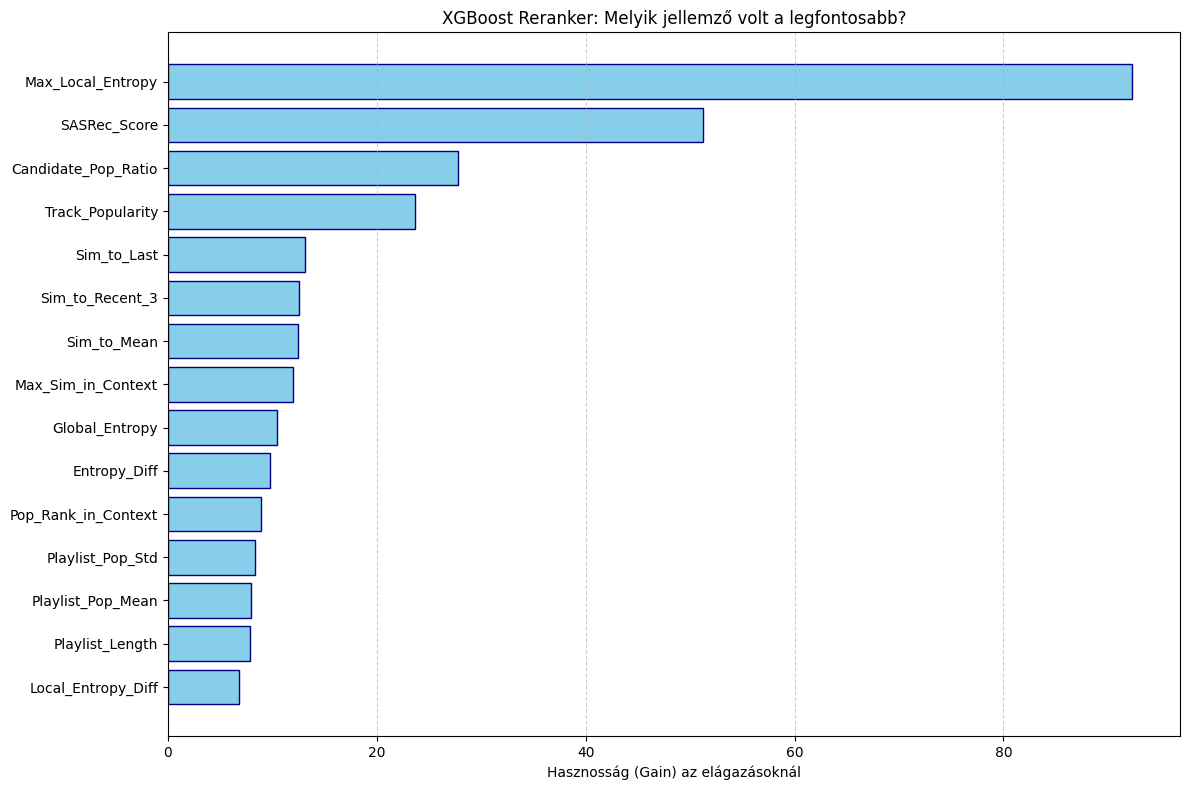


📈 Tanulási görbe...


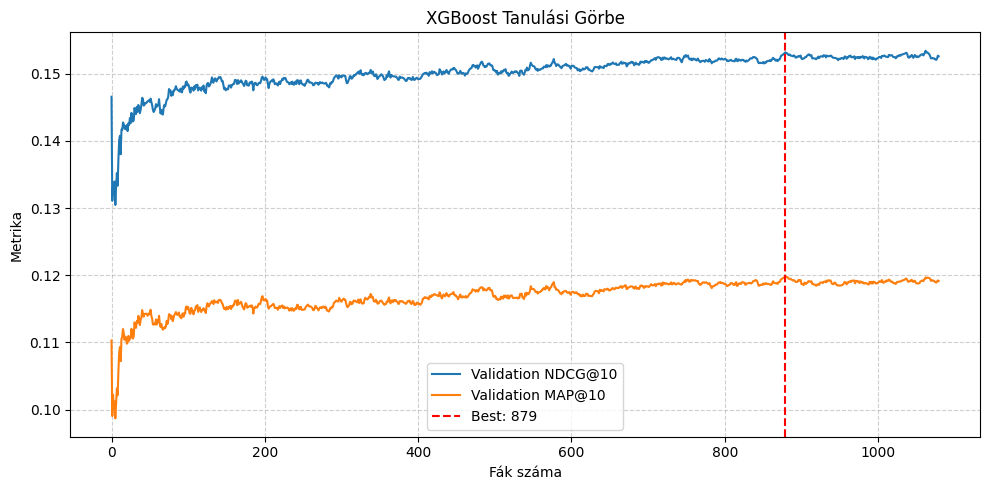

🏆 Legjobb iteráció: 879
🏆 Legjobb NDCG@10: 0.1534


In [ ]:
import pandas as pd
import xgboost as xgb
import matplotlib.pyplot as plt

# ==========================================
# 1. ADATBETÖLTÉS ÉS RENDEZÉS
# ==========================================
print("📂 Parquet fájl betöltése...")
df = pd.read_parquet("../Models/xgboost_train_dataset_hybrid_filtered.parquet")  # ← filtered
df = df.sort_values("Playlist_ID").reset_index(drop=True)

# Listán belüli shuffle — pozitív ne legyen mindig elöl
shuffled_parts = []
for pid, group in df.groupby("Playlist_ID"):
    shuffled_parts.append(group.sample(frac=1, random_state=42))
df = pd.concat(shuffled_parts).reset_index(drop=True)

# ==========================================
# 2. JELLEMZŐK DEFINIÁLÁSA
# ==========================================
features = [
    'Playlist_Length',
    #'SASRec_Rank',
    'SASRec_Score',
    'Sim_to_Last',
    'Sim_to_Mean',
    'Sim_to_Recent_3',       # ← ÚJ
    'Max_Sim_in_Context',    # ← ÚJ
    'Track_Popularity',
    'Global_Entropy',
    'Max_Local_Entropy',
    'Playlist_Pop_Mean',
    'Playlist_Pop_Std',
    'Candidate_Pop_Ratio',
    'Pop_Rank_in_Context',   # ← ÚJ
    'Entropy_Diff',
    'Local_Entropy_Diff'
]

X = df[features]
y = df['Label']
groups = df['Playlist_ID']

# ==========================================
# 3. TRAIN-VAL SPLIT
# ==========================================
total_playlists = groups.max()
train_idx = groups < (total_playlists - 5000)

X_train, y_train, qid_train = X[train_idx], y[train_idx], groups[train_idx]
X_val, y_val, qid_val = X[~train_idx], y[~train_idx], groups[~train_idx]

print(f"✅ Tanító halmaz: {len(X_train):,} sor")
print(f"✅ Validációs halmaz: {len(X_val):,} sor")

# ==========================================
# 4. MODELL DEFINÍCIÓ ÉS TANÍTÁS
# ==========================================
print("\n🚀 XGBoost tanítás indítása...")

ranker = xgb.XGBRanker(
    objective='rank:ndcg',
    n_estimators=2000,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=10,
    tree_method='hist',
    random_state=42,
    eval_metric=['ndcg@10', 'map@10'],
    early_stopping_rounds=200
)

ranker.fit(
    X_train, y_train,
    qid=qid_train,
    eval_set=[(X_val, y_val)],
    eval_qid=[qid_val],
    verbose=50
)

# ==========================================
# 5. MENTÉS ÉS VIZUALIZÁCIÓ
# ==========================================
ranker.save_model("../Models/xgboost_reranker_final_hybrid.json")
print("\n💾 Modell sikeresen elmentve!")

print("\n📊 Jellemzők fontosságának (Feature Importance) kirajzolása...")
importance = ranker.get_booster().get_score(importance_type='gain')
sorted_importance = sorted(importance.items(), key=lambda x: x[1], reverse=True)
labels, values = zip(*sorted_importance)

plt.figure(figsize=(12, 8))
plt.barh(labels[::-1], values[::-1], color='skyblue', edgecolor='navy')
plt.xlabel("Hasznosság (Gain) az elágazásoknál")
plt.title("XGBoost Reranker: Melyik jellemző volt a legfontosabb?")
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

print("\n📈 Tanulási görbe...")
results = ranker.evals_result()
plt.figure(figsize=(10, 5))
plt.plot(results['validation_0']['ndcg@10'], label='Validation NDCG@10')
plt.plot(results['validation_0']['map@10'],  label='Validation MAP@10')
plt.axvline(x=ranker.best_iteration, color='red', linestyle='--',
            label=f'Best: {ranker.best_iteration}')
plt.legend()
plt.title('XGBoost Tanulási Görbe')
plt.xlabel('Fák száma')
plt.ylabel('Metrika')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

print(f"🏆 Legjobb iteráció: {ranker.best_iteration}")
print(f"🏆 Legjobb NDCG@10: {max(results['validation_0']['ndcg@10']):.4f}")

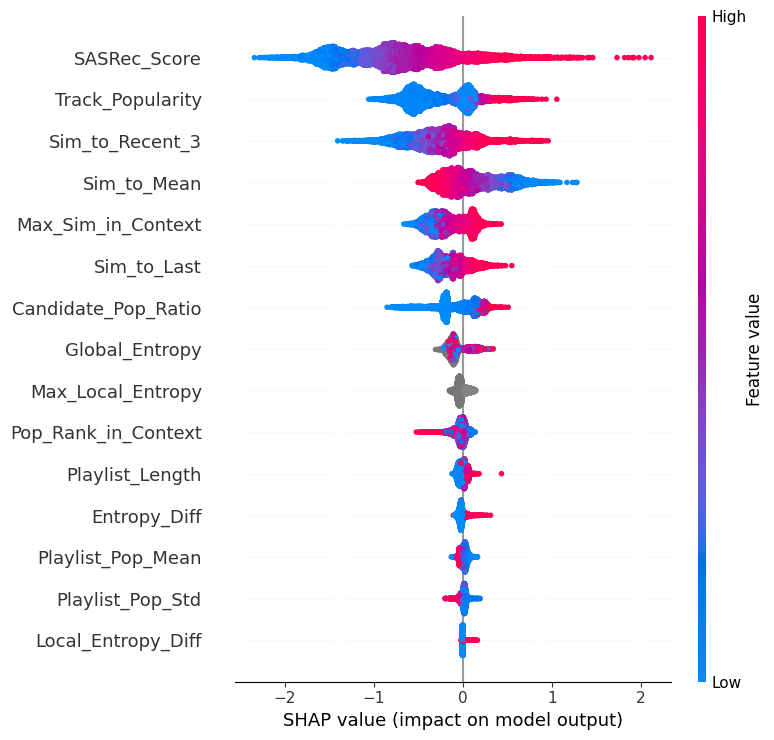

In [1]:
import xgboost as xgb
import shap
import pandas as pd

# Modell betöltése
ranker = xgb.XGBRanker()
ranker.load_model("../Models/xgboost_reranker_final_hybrid.json")

# Validációs adat betöltése (ugyanazok a feature-ök kellenek)
df = pd.read_parquet("../Models/xgboost_train_dataset_hybrid_filtered.parquet")
df = df.sort_values("Playlist_ID").reset_index(drop=True)

features = [
    'Playlist_Length', 'SASRec_Score', 'Sim_to_Last', 'Sim_to_Mean',
    'Sim_to_Recent_3', 'Max_Sim_in_Context', 'Track_Popularity',
    'Global_Entropy', 'Max_Local_Entropy', 'Playlist_Pop_Mean',
    'Playlist_Pop_Std', 'Candidate_Pop_Ratio', 'Pop_Rank_in_Context',
    'Entropy_Diff', 'Local_Entropy_Diff'
]

groups = df['Playlist_ID']
total_playlists = groups.max()
val_idx = groups >= (total_playlists - 5000)
X_val = df.loc[val_idx, features]

# SHAP elemzés
explainer = shap.TreeExplainer(ranker)
shap_values = explainer.shap_values(X_val.iloc[:10_000])

shap.summary_plot(shap_values, X_val.iloc[:10_000], feature_names=features)

## Teszt tábla

In [ ]:
import random
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers
import faiss
import h5py
from gensim.models import Word2Vec
from tqdm.auto import tqdm
import pyarrow as pa
import pyarrow.parquet as pq
import gc

# ==========================================
# 1. ÚTVONALAK ÉS PARAMÉTEREK
# ==========================================
VAL_DATA_PATH   = "../Models/test_pids.npy"
W2V_MODEL_PATH  = "../Models/song2vec.model"
W2V_MATRIX_PATH = "../Models/hybrid_embedding_matrix.npy"
H5_FILE         = "../Dataset/spotify_dataset_compressed.h5"
WEIGHTS_PATH    = "../Models/best_sasrec_large_hard_w2v_only.weights.h5"
OUTPUT_PARQUET  = "../Models/xgboost_test_dataset_hybrid.parquet"

MAX_LEN = 50
BATCH_SIZE = 256
TOP_K = 500

# ==========================================
# 2. METAADATOK ÉS SZÓTÁR ELŐTÖLTÉSE
# ==========================================
print("📖 Word2Vec szótár és beágyazások betöltése...")
w2v_model = Word2Vec.load(W2V_MODEL_PATH)
uri_to_id = w2v_model.wv.key_to_index

embeddings = np.load(W2V_MATRIX_PATH).astype('float32')
vocab_size, D_MODEL = embeddings.shape

embeddings_norm = embeddings.copy()
faiss.normalize_L2(embeddings_norm)

print("📈 Dalok népszerűségének kiszámítása a Train halmazból...")
track_popularity = np.zeros(vocab_size, dtype=int)
train_playlists = np.load("../Models/train_pids.npy", allow_pickle=True)
for pl in train_playlists:
    for track_id in pl:
        if track_id < vocab_size:
            track_popularity[track_id] += 1

track_global_entropy = np.full(vocab_size, np.nan, dtype=np.float32)
track_max_local_entropy = np.full(vocab_size, np.nan, dtype=np.float32)
track_is_cnn = np.zeros(vocab_size, dtype=int)

print("🧮 HDF5 metaadatok beolvasása...")
with h5py.File(H5_FILE, "r") as hf:
    track_uris_hdf5 = hf["ml/track_uri"][:]
    entropy_global_data = hf["features/markov_entropy_global"][:]
    entropy_local_data = hf["features/markov_entropy_local"][:]

    if isinstance(track_uris_hdf5[0], bytes):
        track_uris_hdf5 = [uri.decode('utf-8') for uri in track_uris_hdf5]

    for hdf5_idx, uri in enumerate(tqdm(track_uris_hdf5, desc="Mapping")):
        if uri in uri_to_id:
            sasrec_id = uri_to_id[uri]
            if sasrec_id < vocab_size:
                track_global_entropy[sasrec_id] = entropy_global_data[hdf5_idx][0]
                track_max_local_entropy[sasrec_id] = np.max(entropy_local_data[hdf5_idx])
                track_is_cnn[sasrec_id] = 1

print(f"❄️ Cold Start szimulálva: {(track_is_cnn == 1).sum():,} dal népszerűsége lenullázva.")
track_popularity[track_is_cnn == 1] = 0

# ==========================================
# 3. SASREC MODELL (INFERENCIA VERZIÓ)
# ==========================================
print("🏗️ SASRec Modell inicializálása...")
def create_inference_model(vocab_size, init_weights):
    seq_inputs = layers.Input(shape=(MAX_LEN,), name="seq_inputs")
    item_embedding = layers.Embedding(
        vocab_size, D_MODEL, mask_zero=True,
        embeddings_initializer=tf.keras.initializers.Constant(init_weights),
        trainable=True, name="w2v_embedding"
    )
    pos_embedding = layers.Embedding(MAX_LEN, D_MODEL, name="pos_embedding")
    x = item_embedding(seq_inputs)
    x += pos_embedding(tf.range(MAX_LEN)[tf.newaxis, :])
    for _ in range(3):
        attn = layers.MultiHeadAttention(num_heads=8, key_dim=D_MODEL//8)(x, x, use_causal_mask=True)
        x = layers.LayerNormalization()(x + layers.Dropout(0.2)(attn))
        ffn = layers.Dense(D_MODEL * 4, activation='relu')(x)
        ffn = layers.Dense(D_MODEL)(ffn)
        x = layers.LayerNormalization()(x + layers.Dropout(0.2)(ffn))
    seq_states = layers.Dense(D_MODEL, name="final_projection")(x)
    return tf.keras.Model(inputs=seq_inputs, outputs=seq_states)

inference_model = create_inference_model(vocab_size, embeddings)
inference_model.load_weights(WEIGHTS_PATH)

print("🔍 FAISS Index építése...")
updated_embeddings = inference_model.get_layer("w2v_embedding").get_weights()[0]
faiss_embeddings = updated_embeddings.copy().astype('float32')
faiss.normalize_L2(faiss_embeddings)
index = faiss.IndexFlatIP(D_MODEL)
index.add(faiss_embeddings)

# ==========================================
# 4. KÖTEGELT TÁBLÁZATGENERÁLÁS (STREAMINGGEL)
# ==========================================
print("🚀 Táblázat generálása és folyamatos lemezre írása...")
val_playlists = np.load(VAL_DATA_PATH, allow_pickle=True)
val_playlists = np.array([[t for t in pl if t != 0] for pl in val_playlists], dtype=object)

dataset_rows = []
global_playlist_id = 0
writer = None

for i in tqdm(range(0, len(val_playlists), BATCH_SIZE), desc="SASRec Predikciók"):
    batch_lists = val_playlists[i : i + BATCH_SIZE]
    batch_padded, targets, valid_contexts = [], [], []

    for pl in batch_lists:
        if len(pl) < 2: continue
        targets.append(pl[-1])
        context = pl[:-1]
        valid_contexts.append(context)
        input_seq = context[-MAX_LEN:]
        batch_padded.append([0] * (MAX_LEN - len(input_seq)) + list(input_seq))

    if not batch_padded: continue

    pred_vectors = inference_model.predict_on_batch(np.array(batch_padded))
    target_pred_vectors = pred_vectors[:, -1, :].astype('float32')
    faiss.normalize_L2(target_pred_vectors)
    raw_scores, raw_indices = index.search(target_pred_vectors, TOP_K + MAX_LEN)

    for b_idx in range(len(valid_contexts)):
        context = valid_contexts[b_idx]
        actual_target = targets[b_idx]
        last_track_vec = embeddings_norm[context[-1]]

        playlist_mean_vec = np.mean(embeddings_norm[context], axis=0)
        playlist_mean_vec /= (np.linalg.norm(playlist_mean_vec) + 1e-8)

        context_pops = [track_popularity[t] for t in context]
        playlist_pop_mean = float(np.mean(context_pops))
        playlist_pop_std = float(np.std(context_pops))

        context_entropies = [track_global_entropy[t] for t in context
                             if not np.isnan(track_global_entropy[t])]
        playlist_entropy_mean = float(np.mean(context_entropies)) \
                                if len(context_entropies) > 0 else 0.0

        context_local_entropies = [track_max_local_entropy[t] for t in context
                                   if not np.isnan(track_max_local_entropy[t])]
        playlist_local_entropy_mean = float(np.mean(context_local_entropies)) \
                                      if len(context_local_entropies) > 0 else 0.0

        # ← ÚJ: Playlist szintű számítások amik minden jelöltre ugyanazok
        recent_3 = context[-3:]
        recent_3_vecs = embeddings_norm[recent_3]  # (3, D) mátrix

        # Playlist dalok népszerűsége tömbként — Pop_Rank_in_Context-hez
        context_pops_arr = np.array(context_pops)

        # Max hasonlóság a kontextusban — előre kiszámolva
        # (context_size, D) @ (D,) → (context_size,) dot productok
        context_vecs = embeddings_norm[list(context)]  # (N, D)

        pos_samples, neg_samples = [], []
        current_rank = 1

        for score, cand_id in zip(raw_scores[b_idx], raw_indices[b_idx]):
            if cand_id in context or cand_id == 0: continue
            if len(pos_samples) + len(neg_samples) >= TOP_K: break

            is_target = 1 if cand_id == actual_target else 0
            cand_vec = embeddings_norm[cand_id]
            cand_pop = track_popularity[cand_id]
            cand_entropy = track_global_entropy[cand_id]
            cand_local_entropy = track_max_local_entropy[cand_id]

            pop_ratio = cand_pop / (playlist_pop_mean + 1.0)
            entropy_diff = abs(cand_entropy - playlist_entropy_mean) \
                           if not np.isnan(cand_entropy) else -1.0
            local_entropy_diff = abs(cand_local_entropy - playlist_local_entropy_mean) \
                                 if not np.isnan(cand_local_entropy) else -1.0

            # ← ÚJ FEATURE-ÖK
            # 1. Utolsó 3 dal átlagos hasonlósága
            sim_to_recent_3 = float(np.mean(recent_3_vecs @ cand_vec))

            # 2. Leghasonlóbb dal a kontextusban
            max_sim_in_context = float(np.max(context_vecs @ cand_vec))

            # 3. Hány kontextus dal népszerűbb a jelöltnél (arány)
            pop_rank_in_context = float(np.mean(context_pops_arr > cand_pop))

            row = {
                "Playlist_ID": global_playlist_id,
                "Candidate_ID": cand_id,
                "Playlist_Length": len(context),
                "SASRec_Rank": current_rank,
                "SASRec_Score": float(score),
                "Sim_to_Last": float(np.dot(last_track_vec, cand_vec)),
                "Sim_to_Mean": float(np.dot(playlist_mean_vec, cand_vec)),
                "Sim_to_Recent_3": sim_to_recent_3,       # ← ÚJ
                "Max_Sim_in_Context": max_sim_in_context, # ← ÚJ
                "Track_Popularity": cand_pop,
                "Global_Entropy": cand_entropy,
                "Max_Local_Entropy": cand_local_entropy,
                "Playlist_Pop_Mean": playlist_pop_mean,
                "Playlist_Pop_Std": playlist_pop_std,
                "Candidate_Pop_Ratio": float(pop_ratio),
                "Pop_Rank_in_Context": pop_rank_in_context, # ← ÚJ
                "Entropy_Diff": float(entropy_diff),
                "Local_Entropy_Diff": float(local_entropy_diff),
                "Label": is_target
            }

            if is_target:
                pos_samples.append(row)
            else:
                neg_samples.append(row)
            current_rank += 1

        dataset_rows.extend(pos_samples)
        dataset_rows.extend(neg_samples)
        global_playlist_id += 1

    # --- FLUSH ---
    if len(dataset_rows) >= 500000:
        df_chunk = pd.DataFrame(dataset_rows)
        table = pa.Table.from_pandas(df_chunk)
        if writer is None:
            writer = pq.ParquetWriter(OUTPUT_PARQUET, table.schema)
        writer.write_table(table)
        dataset_rows.clear()
        del df_chunk, table
        gc.collect()

# ==========================================
# 5. MARADÉK KIÍRÁSA ÉS FÁJL LEZÁRÁSA
# ==========================================
print("💾 Maradék adatok mentése és fájl lezárása...")
if len(dataset_rows) > 0:
    df_chunk = pd.DataFrame(dataset_rows)
    table = pa.Table.from_pandas(df_chunk)
    if writer is None:
        writer = pq.ParquetWriter(OUTPUT_PARQUET, table.schema)
    writer.write_table(table)

if writer is not None:
    writer.close()

# ==========================================
# 6. SZŰRÉS
# ==========================================
print("🧹 Pozitív nélküli listák szűrése...")
df = pd.read_parquet(OUTPUT_PARQUET)
lists_with_pos = df[df['Label'] == 1]['Playlist_ID'].unique()
df_filtered = df[df['Playlist_ID'].isin(lists_with_pos)].reset_index(drop=True)
df_filtered.to_parquet(OUTPUT_PARQUET.replace('.parquet', '_filtered.parquet'), index=False)

print(f"🎉 KÉSZ! Generált sorok: {len(df):,} → Szűrt sorok: {len(df_filtered):,}")
del df, df_filtered
gc.collect()

📖 Word2Vec szótár és beágyazások betöltése...
📈 Dalok népszerűségének kiszámítása a Train halmazból...
🧮 HDF5 metaadatok beolvasása...


Mapping:   0%|          | 0/27052 [00:00<?, ?it/s]

❄️ Cold Start szimulálva: 25,511 dal népszerűsége lenullázva.
🏗️ SASRec Modell inicializálása...
🔍 FAISS Index építése...
🚀 Táblázat generálása és folyamatos lemezre írása...


SASRec Predikciók:   0%|          | 0/388 [00:00<?, ?it/s]

💾 Maradék adatok mentése és fájl lezárása...
🧹 Pozitív nélküli listák szűrése...
🎉 KÉSZ! Generált sorok: 49,354,168 → Szűrt sorok: 22,564,094


19

## Kiértékelés

In [6]:
import pandas as pd
import numpy as np
import xgboost as xgb

df_test = pd.read_parquet("../Models/xgboost_test_dataset_hybrid.parquet")

features = [
    'Playlist_Length',
    'SASRec_Score',
    'Sim_to_Last',
    'Sim_to_Mean',
    'Sim_to_Recent_3',       # ← ÚJ
    'Max_Sim_in_Context',    # ← ÚJ
    'Track_Popularity',
    'Global_Entropy',
    'Max_Local_Entropy',
    'Playlist_Pop_Mean',
    'Playlist_Pop_Std',
    'Candidate_Pop_Ratio',
    'Pop_Rank_in_Context',   # ← ÚJ
    'Entropy_Diff',
    'Local_Entropy_Diff'
]

ranker = xgb.XGBRanker()
ranker.load_model("../Models/xgboost_reranker_final_hybrid.json")

df_test['XGB_Score'] = ranker.predict(df_test[features])
df_test['XGB_Rank'] = df_test.groupby('Playlist_ID')['XGB_Score'].rank(
    ascending=False, method='first'
).astype(int)

def calculate_metrics(df, rank_col, k_list):
    hits_df = df[df['Label'] == 1].copy()
    pos_ranks = hits_df[rank_col].values
    total_queries = df['Playlist_ID'].nunique()
    
    results = []
    for k in k_list:
        hr    = (pos_ranks <= k).sum() / total_queries
        ndcg  = np.sum([1/np.log2(r+1) if r <= k else 0 for r in pos_ranks]) / total_queries
        map_k = np.sum([1/r if r <= k else 0 for r in pos_ranks]) / total_queries
        results.append({'k': k, 'HR': hr, 'NDCG': ndcg, 'MAP': map_k})
    
    def get_click(r):
        if r > 500 or pd.isna(r): return 51
        return (int(r) - 1) // 10
    avg_clicks = hits_df[rank_col].apply(get_click).sum()
    missing = total_queries - len(hits_df)
    avg_clicks = (avg_clicks + missing * 51) / total_queries
    
    return pd.DataFrame(results), avg_clicks

K_VALUES = [1, 5, 10, 20, 50, 100, 200, 500]
sas_m, sas_c = calculate_metrics(df_test, 'SASRec_Rank', K_VALUES)
xgb_m, xgb_c = calculate_metrics(df_test, 'XGB_Rank',   K_VALUES)

summary = sas_m.set_index('k').join(xgb_m.set_index('k'), lsuffix='_SAS', rsuffix='_XGB')
for m in ['HR', 'NDCG', 'MAP']:
    summary[f'{m}_imp%'] = (summary[f'{m}_XGB'] - summary[f'{m}_SAS']) / summary[f'{m}_SAS'] * 100

print("\n" + "="*70)
print("🏆 EREDMÉNYEK")
print("="*70)
pd.options.display.float_format = '{:.4f}'.format
cols = [c for m in ['HR','NDCG','MAP'] for c in [f'{m}_SAS', f'{m}_XGB', f'{m}_imp%']]
print(summary[cols].T.to_string())
print(f"\n🖱️ Clicks SASRec:  {sas_c:.4f}")
print(f"🖱️ Clicks XGBoost: {xgb_c:.4f}")
print(f"🚀 Clicks javulás: {(xgb_c - sas_c)/sas_c*100:.2f}%")


🏆 EREDMÉNYEK
k             1       5       10      20      50      100     200     500
HR_SAS     0.0221  0.0624  0.0938  0.1319  0.2005  0.2675  0.3443  0.4578
HR_XGB     0.0314  0.0811  0.1168  0.1639  0.2448  0.3196  0.3969  0.4578
HR_imp%   42.1461 30.0129 24.6156 24.2737 22.0920 19.4512 15.2693  0.0000
NDCG_SAS   0.0221  0.0425  0.0526  0.0622  0.0758  0.0866  0.0973  0.1110
NDCG_XGB   0.0314  0.0565  0.0680  0.0799  0.0959  0.1080  0.1188  0.1263
NDCG_imp% 42.1461 32.9306 29.3678 28.4456 26.5596 24.6993 22.0910 13.7765
MAP_SAS    0.0221  0.0360  0.0401  0.0427  0.0449  0.0458  0.0464  0.0467
MAP_XGB    0.0314  0.0484  0.0532  0.0564  0.0590  0.0600  0.0606  0.0608
MAP_imp%  42.1461 34.6200 32.6040 32.0376 31.3603 30.9641 30.6265 30.0596

🖱️ Clicks SASRec:  33.0818
🖱️ Clicks XGBoost: 31.2668
🚀 Clicks javulás: -5.49%


# Mel + Chroma + Tempo (kevesebb feature)

## Kolleráció vizsgálat

📂 Minta betöltése (első 500k sor elég a korreláció becsléshez)...
📊 Korrelációs mátrix számítása...


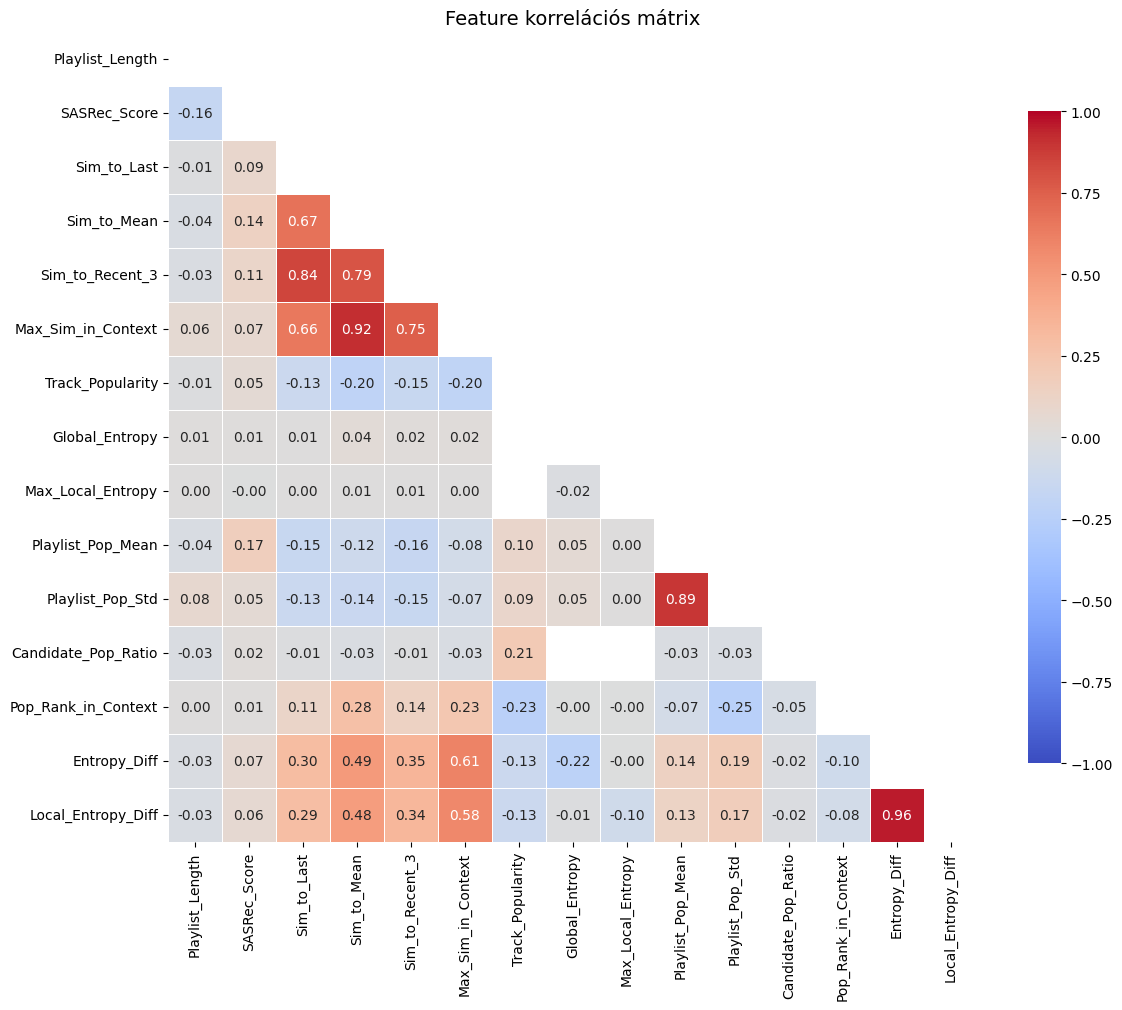


⚠️ Erős korreláció (|r| > 0.7):
  Sim_to_Recent_3 <-> Sim_to_Last: 0.845
  Sim_to_Recent_3 <-> Sim_to_Mean: 0.794
  Max_Sim_in_Context <-> Sim_to_Mean: 0.920
  Max_Sim_in_Context <-> Sim_to_Recent_3: 0.752
  Playlist_Pop_Std <-> Playlist_Pop_Mean: 0.891
  Local_Entropy_Diff <-> Entropy_Diff: 0.960


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

features = [
    'Playlist_Length',
    'SASRec_Score',
    'Sim_to_Last',
    'Sim_to_Mean',
    'Sim_to_Recent_3',       # ← ÚJ
    'Max_Sim_in_Context',    # ← ÚJ
    'Track_Popularity',
    'Global_Entropy',
    'Max_Local_Entropy',
    'Playlist_Pop_Mean',
    'Playlist_Pop_Std',
    'Candidate_Pop_Ratio',
    'Pop_Rank_in_Context',   # ← ÚJ
    'Entropy_Diff',
    'Local_Entropy_Diff',
]

print("📂 Minta betöltése (első 500k sor elég a korreláció becsléshez)...")
df = pd.read_parquet(
    "../Models/xgboost_train_dataset_hybrid_filtered.parquet",
    columns=features
).head(500_000)

print("📊 Korrelációs mátrix számítása...")
corr = df[features].corr()

plt.figure(figsize=(12, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))  # Csak az alsó háromszög
sns.heatmap(
    corr,
    mask=mask,
    annot=True,       # Számok kiírása
    fmt=".2f",        # 2 tizedesjegy
    cmap="coolwarm",  # Piros = pozitív, kék = negatív korreláció
    center=0,
    vmin=-1, vmax=1,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)
plt.title("Feature korrelációs mátrix", fontsize=14)
plt.tight_layout()
plt.show()

# Szöveges összefoglaló: mely párok korrelálnak erősen (|r| > 0.7)?
print("\n⚠️ Erős korreláció (|r| > 0.7):")
for i in range(len(corr.columns)):
    for j in range(i):
        val = corr.iloc[i, j]
        if abs(val) > 0.7:
            print(f"  {corr.columns[i]} <-> {corr.columns[j]}: {val:.3f}")

## Tanító tábla

In [ ]:
import random
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers
import faiss
import h5py
from gensim.models import Word2Vec
from tqdm.auto import tqdm
import pyarrow as pa
import pyarrow.parquet as pq
import gc

# ==========================================
# 1. ÚTVONALAK ÉS PARAMÉTEREK
# ==========================================
VAL_DATA_PATH   = "../Models/val_pids.npy"
W2V_MODEL_PATH  = "../Models/song2vec.model"
W2V_MATRIX_PATH = "../Models/hybrid_embedding_matrix.npy"
H5_FILE         = "../Dataset/spotify_dataset_compressed.h5"
WEIGHTS_PATH    = "../Models/best_sasrec_large_hard_w2v_only.weights.h5"
OUTPUT_PARQUET  = "../Models/xgboost_train_dataset_hybrid_v2.parquet"

MAX_LEN = 50
BATCH_SIZE = 256
TOP_K = 500

# ==========================================
# 2. METAADATOK ÉS SZÓTÁR ELŐTÖLTÉSE
# ==========================================
print("📖 Word2Vec szótár és beágyazások betöltése...")
w2v_model = Word2Vec.load(W2V_MODEL_PATH)
uri_to_id = w2v_model.wv.key_to_index

embeddings = np.load(W2V_MATRIX_PATH).astype('float32')
vocab_size, D_MODEL = embeddings.shape

embeddings_norm = embeddings.copy()
faiss.normalize_L2(embeddings_norm)

print("📈 Dalok népszerűségének kiszámítása a Train halmazból...")
track_popularity = np.zeros(vocab_size, dtype=int)
train_playlists = np.load("../Models/train_pids.npy", allow_pickle=True)
for pl in train_playlists:
    for track_id in pl:
        if track_id < vocab_size:
            track_popularity[track_id] += 1

track_global_entropy = np.full(vocab_size, np.nan, dtype=np.float32)
track_max_local_entropy = np.full(vocab_size, np.nan, dtype=np.float32)
track_is_cnn = np.zeros(vocab_size, dtype=int)

print("🧮 HDF5 metaadatok beolvasása...")
with h5py.File(H5_FILE, "r") as hf:
    track_uris_hdf5 = hf["ml/track_uri"][:]
    entropy_global_data = hf["features/markov_entropy_global"][:]
    entropy_local_data = hf["features/markov_entropy_local"][:]
    
    if isinstance(track_uris_hdf5[0], bytes):
        track_uris_hdf5 = [uri.decode('utf-8') for uri in track_uris_hdf5]
        
    for hdf5_idx, uri in enumerate(tqdm(track_uris_hdf5, desc="Mapping")):
        if uri in uri_to_id:
            sasrec_id = uri_to_id[uri]
            if sasrec_id < vocab_size:
                track_global_entropy[sasrec_id] = entropy_global_data[hdf5_idx][0]
                track_max_local_entropy[sasrec_id] = np.max(entropy_local_data[hdf5_idx])
                track_is_cnn[sasrec_id] = 1

print(f"❄️ Cold Start szimulálva: {(track_is_cnn == 1).sum():,} dal népszerűsége lenullázva.")
track_popularity[track_is_cnn == 1] = 0

# ==========================================
# 3. SASREC MODELL (INFERENCIA VERZIÓ)
# ==========================================
print("🏗️ SASRec Modell inicializálása...")
def create_inference_model(vocab_size, init_weights):
    seq_inputs = layers.Input(shape=(MAX_LEN,), name="seq_inputs")
    item_embedding = layers.Embedding(
        vocab_size, D_MODEL, mask_zero=True,
        embeddings_initializer=tf.keras.initializers.Constant(init_weights),
        trainable=True, name="w2v_embedding"
    )
    pos_embedding = layers.Embedding(MAX_LEN, D_MODEL, name="pos_embedding")
    x = item_embedding(seq_inputs)
    x += pos_embedding(tf.range(MAX_LEN)[tf.newaxis, :])
    for _ in range(3):
        attn = layers.MultiHeadAttention(num_heads=8, key_dim=D_MODEL//8)(x, x, use_causal_mask=True)
        x = layers.LayerNormalization()(x + layers.Dropout(0.2)(attn))
        ffn = layers.Dense(D_MODEL * 4, activation='relu')(x)
        ffn = layers.Dense(D_MODEL)(ffn)
        x = layers.LayerNormalization()(x + layers.Dropout(0.2)(ffn))
    seq_states = layers.Dense(D_MODEL, name="final_projection")(x)
    return tf.keras.Model(inputs=seq_inputs, outputs=seq_states)

inference_model = create_inference_model(vocab_size, embeddings)
inference_model.load_weights(WEIGHTS_PATH)

print("🔍 FAISS Index építése...")
updated_embeddings = inference_model.get_layer("w2v_embedding").get_weights()[0]
faiss_embeddings = updated_embeddings.copy().astype('float32')
faiss.normalize_L2(faiss_embeddings)
index = faiss.IndexFlatIP(D_MODEL)
index.add(faiss_embeddings)

# ==========================================
# 4. KÖTEGELT TÁBLÁZATGENERÁLÁS (STREAMINGGEL)
# ==========================================
print("🚀 Táblázat generálása és folyamatos lemezre írása...")
val_playlists = np.load(VAL_DATA_PATH, allow_pickle=True)
val_playlists = np.array([[t for t in pl if t != 0] for pl in val_playlists], dtype=object)

dataset_rows = []
global_playlist_id = 0
writer = None  # Folyamatos Parquet writer

for i in tqdm(range(0, len(val_playlists), BATCH_SIZE), desc="SASRec Predikciók"):
    batch_lists = val_playlists[i : i + BATCH_SIZE]
    batch_padded, targets, valid_contexts = [], [], []
    
    for pl in batch_lists:
        if len(pl) < 2: continue
        targets.append(pl[-1])
        context = pl[:-1]
        valid_contexts.append(context)
        input_seq = context[-MAX_LEN:]
        batch_padded.append([0] * (MAX_LEN - len(input_seq)) + list(input_seq))
        
    if not batch_padded: continue
    
    pred_vectors = inference_model.predict_on_batch(np.array(batch_padded))
    target_pred_vectors = pred_vectors[:, -1, :].astype('float32')
    faiss.normalize_L2(target_pred_vectors)
    
    raw_scores, raw_indices = index.search(target_pred_vectors, TOP_K + MAX_LEN)
    
    for b_idx in range(len(valid_contexts)):
        context = valid_contexts[b_idx]
        actual_target = targets[b_idx]
        last_track_vec = embeddings_norm[context[-1]]
        
        playlist_mean_vec = np.mean(embeddings_norm[context], axis=0)
        playlist_mean_vec /= (np.linalg.norm(playlist_mean_vec) + 1e-8)
        
        context_pops = [track_popularity[t] for t in context]
        playlist_pop_mean = float(np.mean(context_pops))
        
        context_entropies = [track_global_entropy[t] for t in context if not np.isnan(track_global_entropy[t])]
        playlist_entropy_mean = float(np.mean(context_entropies)) if len(context_entropies) > 0 else 0.0
        
        pos_samples = []
        neg_samples = []
        current_rank = 1

        for score, cand_id in zip(raw_scores[b_idx], raw_indices[b_idx]):
            if cand_id in context or cand_id == 0: continue
            if len(pos_samples) + len(neg_samples) >= TOP_K: break
            
            is_target = 1 if cand_id == actual_target else 0
            cand_vec = embeddings_norm[cand_id]
            cand_pop = track_popularity[cand_id]
            cand_entropy = track_global_entropy[cand_id]
            cand_local_entropy = track_max_local_entropy[cand_id]
            
            pop_ratio = cand_pop / (playlist_pop_mean + 1.0)
            entropy_diff = abs(cand_entropy - playlist_entropy_mean) if not np.isnan(cand_entropy) else -1.0
            
            row = {
                "Playlist_ID": global_playlist_id,
                "Candidate_ID": cand_id,
                "SASRec_Rank": current_rank,
                "Relative_Rank": float(current_rank / TOP_K),
                "SASRec_Score": float(score),
                "Sim_to_Last": float(np.dot(last_track_vec, cand_vec)),
                "Sim_to_Mean": float(np.dot(playlist_mean_vec, cand_vec)),
                "Track_Popularity": cand_pop,
                "Global_Entropy": cand_entropy,
                "Max_Local_Entropy": cand_local_entropy,
                "Candidate_Pop_Ratio": float(pop_ratio),
                "Entropy_Diff": float(entropy_diff),
                "Is_CNN_Only": track_is_cnn[cand_id],
                "Label": is_target
            }

            if is_target:
                pos_samples.append(row)
            else:
                neg_samples.append(row)
            current_rank += 1

        dataset_rows.extend(pos_samples)
        dataset_rows.extend(neg_samples)
        global_playlist_id += 1

    # --- FLUSH: minden 500.000 sor után lemezre írás ---
    if len(dataset_rows) >= 500000:
        df_chunk = pd.DataFrame(dataset_rows)
        table = pa.Table.from_pandas(df_chunk)
        
        if writer is None:
            writer = pq.ParquetWriter(OUTPUT_PARQUET, table.schema)
        writer.write_table(table)
        
        dataset_rows.clear()
        del df_chunk, table
        gc.collect()

# ==========================================
# 5. MARADÉK KIÍRÁSA ÉS FÁJL LEZÁRÁSA
# ==========================================
print("💾 Maradék adatok mentése és fájl lezárása...")
if len(dataset_rows) > 0:
    df_chunk = pd.DataFrame(dataset_rows)
    table = pa.Table.from_pandas(df_chunk)
    if writer is None:
        writer = pq.ParquetWriter(OUTPUT_PARQUET, table.schema)
    writer.write_table(table)

if writer is not None:
    writer.close()

print(f"🎉 KÉSZ! Az összes adat (kb. {global_playlist_id * TOP_K:,} sor) sikeresen lemezre írva.")

📖 Word2Vec szótár és beágyazások betöltése...
📈 Dalok népszerűségének kiszámítása a Train halmazból...
🧮 HDF5 metaadatok beolvasása...


Mapping:   0%|          | 0/27052 [00:00<?, ?it/s]

❄️ Cold Start szimulálva: 25,511 dal népszerűsége lenullázva.
🏗️ SASRec Modell inicializálása...
🔍 FAISS Index építése...
🚀 Táblázat generálása és folyamatos lemezre írása...


SASRec Predikciók:   0%|          | 0/388 [00:00<?, ?it/s]

💾 Maradék adatok mentése és fájl lezárása...
🎉 KÉSZ! Az összes adat (kb. 49,589,500 sor) sikeresen lemezre írva.


In [ ]:
import pandas as pd
import pyarrow as pa
import pyarrow.parquet as pq
import gc

INPUT_PARQUET  = "../Models/xgboost_train_dataset_hybrid_v2.parquet"
OUTPUT_PARQUET = "../Models/xgboost_train_dataset_hybrid_v2_filtered.parquet"

print("📂 Pozitív Playlist_ID-k beolvasása...")
# Csak a Label oszlopot olvassuk be először — gyors és memóriakímélő
df_labels = pd.read_parquet(INPUT_PARQUET, columns=['Playlist_ID', 'Label'])
lists_with_pos = set(df_labels[df_labels['Label'] == 1]['Playlist_ID'].unique())
del df_labels
gc.collect()
print(f"✅ Megtartandó listák száma: {len(lists_with_pos):,}")

print("📖 Szűrés és streaming írás...")
parquet_file = pq.ParquetFile(INPUT_PARQUET)
writer = None

for batch in parquet_file.iter_batches(batch_size=500_000):
    df_chunk = batch.to_pandas()
    df_filtered = df_chunk[df_chunk['Playlist_ID'].isin(lists_with_pos)]
    
    if len(df_filtered) == 0:
        continue
    
    table = pa.Table.from_pandas(df_filtered, preserve_index=False)
    if writer is None:
        writer = pq.ParquetWriter(OUTPUT_PARQUET, table.schema)
    writer.write_table(table)
    
    del df_chunk, df_filtered, table
    gc.collect()

if writer is not None:
    writer.close()

print("🎉 KÉSZ! Szűrt fájl elmentve.")

📂 Pozitív Playlist_ID-k beolvasása...
✅ Megtartandó listák száma: 45,392
📖 Szűrés és streaming írás...
🎉 KÉSZ! Szűrt fájl elmentve.


## Tanítás

📂 Parquet fájl betöltése...
✅ Tanító halmaz: 21,463,303 sor
✅ Validációs halmaz: 1,143,152 sor

🚀 XGBoost tanítás indítása...
[0]	validation_0-ndcg@10:0.14192	validation_0-map@10:0.10864
[50]	validation_0-ndcg@10:0.14863	validation_0-map@10:0.11611
[100]	validation_0-ndcg@10:0.14746	validation_0-map@10:0.11511
[150]	validation_0-ndcg@10:0.14872	validation_0-map@10:0.11611
[200]	validation_0-ndcg@10:0.14963	validation_0-map@10:0.11707
[250]	validation_0-ndcg@10:0.14860	validation_0-map@10:0.11625
[300]	validation_0-ndcg@10:0.14983	validation_0-map@10:0.11678
[350]	validation_0-ndcg@10:0.14973	validation_0-map@10:0.11693
[400]	validation_0-ndcg@10:0.14939	validation_0-map@10:0.11689
[450]	validation_0-ndcg@10:0.14992	validation_0-map@10:0.11790
[500]	validation_0-ndcg@10:0.15115	validation_0-map@10:0.11900
[550]	validation_0-ndcg@10:0.15073	validation_0-map@10:0.11826
[600]	validation_0-ndcg@10:0.15160	validation_0-map@10:0.11918
[650]	validation_0-ndcg@10:0.15169	validation_0-map@10:0.1

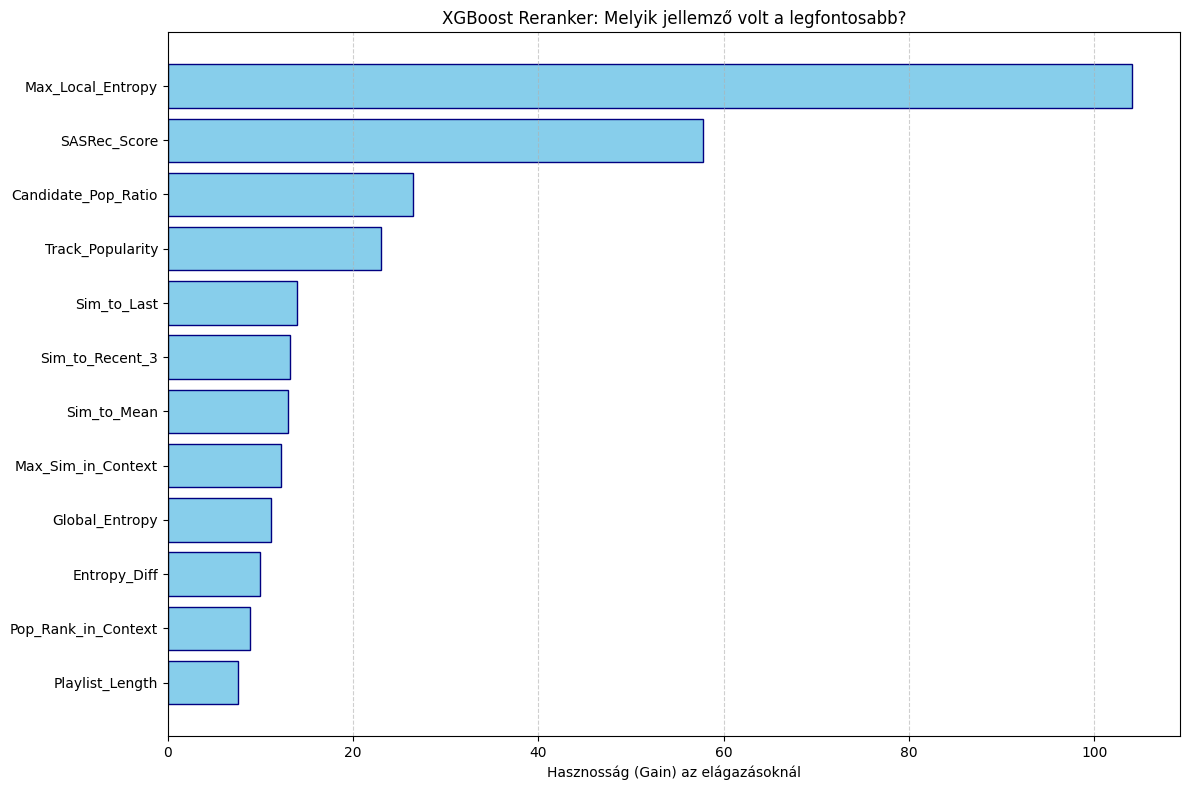

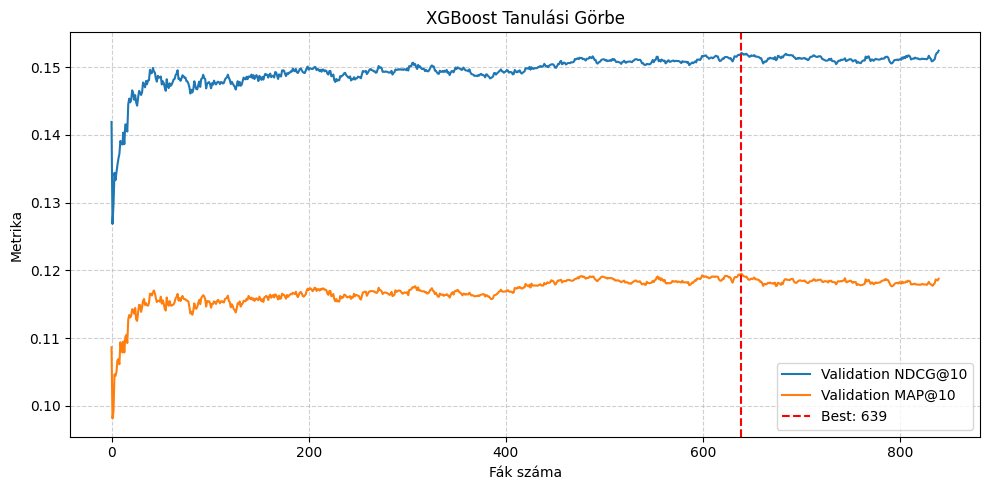

🏆 Legjobb iteráció: 639
🏆 Legjobb NDCG@10: 0.1524


In [2]:
import pandas as pd
import xgboost as xgb
import matplotlib.pyplot as plt

# ==========================================
# 1. ADATBETÖLTÉS ÉS RENDEZÉS
# ==========================================
print("📂 Parquet fájl betöltése...")
df = pd.read_parquet("../Models/xgboost_train_dataset_hybrid_filtered.parquet")
df = df.sort_values("Playlist_ID").reset_index(drop=True)

shuffled_parts = []
for pid, group in df.groupby("Playlist_ID"):
    shuffled_parts.append(group.sample(frac=1, random_state=42))
df = pd.concat(shuffled_parts).reset_index(drop=True)

# ==========================================
# 2. JELLEMZŐK DEFINIÁLÁSA
# ==========================================
# A Playlist_ID és Candidate_ID azonosítók, ezeket nem tanítjuk!
# BELEKERÜLTEK AZ ÚJ RELATÍV ÉS NORMALIZÁLT JELLEMZŐK:
features = [
    'Playlist_Length',
    #'SASRec_Rank',
    'SASRec_Score',
    'Sim_to_Last',
    'Sim_to_Mean',
    'Sim_to_Recent_3',       # ← ÚJ
    'Max_Sim_in_Context',    # ← ÚJ
    'Track_Popularity',
    'Global_Entropy',
    'Max_Local_Entropy',
    'Candidate_Pop_Ratio',
    'Pop_Rank_in_Context',   # ← ÚJ
    'Entropy_Diff',
]

X = df[features]
y = df['Label']
groups = df['Playlist_ID']

# ==========================================
# 3. TRAIN-VAL SPLIT
# ==========================================
# Különválasztunk egy kis részt (pl. 5000 listát) ellenőrzésnek a tanítás alatt
total_playlists = groups.max()
train_idx = groups < (total_playlists - 5000)

X_train, y_train, qid_train = X[train_idx], y[train_idx], groups[train_idx]
X_val, y_val, qid_val = X[~train_idx], y[~train_idx], groups[~train_idx]

print(f"✅ Tanító halmaz: {len(X_train):,} sor")
print(f"✅ Validációs halmaz: {len(X_val):,} sor")

# ==========================================
# 4. MODELL DEFINÍCIÓ ÉS TANÍTÁS
# ==========================================
print("\n🚀 XGBoost tanítás indítása...")

ranker = xgb.XGBRanker(
    objective='rank:ndcg',       # ÚJ: Próbáld ki a Pairwise rangsorolást! (vagy hagyd rank:ndcg-n)
    n_estimators=2000,               # ÚJ: Felemelve 2000-re, az Early Stopping majd megállítja!
    learning_rate=0.05,              
    max_depth=6,                     
    subsample=0.8,                   
    colsample_bytree=0.8,            
    min_child_weight=10,              
    tree_method='hist',              
    random_state=42,
    # ÚJ: Több metrika figyelése! Az első metrika alapján fog működni az early_stopping.
    eval_metric=['ndcg@10', 'map@10'], 
    early_stopping_rounds=200        
)

# Tanítás monitoringgal
eval_result = ranker.fit(
    X_train, y_train,
    qid=qid_train,
    eval_set=[(X_val, y_val)], # ÚJ: A Train-t is betesszük, hogy lássuk az Overfittinget!
    eval_qid=[qid_val],
    verbose=50 # ÚJ: Elég 50 fánként kiírni, ha 2000 a max
)

# ==========================================
# 5. MENTÉS ÉS VIZUALIZÁCIÓ
# ==========================================
ranker.save_model("../Models/xgboost_reranker_final_hybrid_v2.json")
print("\n💾 Modell sikeresen elmentve!")

print("\n📊 Jellemzők fontosságának (Feature Importance) kirajzolása...")
importance = ranker.get_booster().get_score(importance_type='gain')
sorted_importance = sorted(importance.items(), key=lambda x: x[1], reverse=True)
labels, values = zip(*sorted_importance)

plt.figure(figsize=(12, 8))
plt.barh(labels[::-1], values[::-1], color='skyblue', edgecolor='navy')
plt.xlabel("Hasznosság (Gain) az elágazásoknál")
plt.title("XGBoost Reranker: Melyik jellemző volt a legfontosabb?")
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

results = ranker.evals_result()
epochs = len(results['validation_0']['ndcg@10'])

plt.figure(figsize=(10, 5))
plt.plot(results['validation_0']['ndcg@10'], label='Validation NDCG@10')
plt.plot(results['validation_0']['map@10'],  label='Validation MAP@10')
plt.axvline(x=ranker.best_iteration, color='red', linestyle='--', label=f'Best: {ranker.best_iteration}')
plt.legend()
plt.title('XGBoost Tanulási Görbe')
plt.xlabel('Fák száma')
plt.ylabel('Metrika')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

print(f"🏆 Legjobb iteráció: {ranker.best_iteration}")
print(f"🏆 Legjobb NDCG@10: {max(results['validation_0']['ndcg@10']):.4f}")

## Teszt tábla

In [ ]:
import random
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers
import faiss
import h5py
from gensim.models import Word2Vec
from tqdm.auto import tqdm
import pyarrow as pa
import pyarrow.parquet as pq
import gc

# ==========================================
# 1. ÚTVONALAK ÉS PARAMÉTEREK
# ==========================================
VAL_DATA_PATH   = "../Models/test_pids.npy"
W2V_MODEL_PATH  = "../Models/song2vec.model"
W2V_MATRIX_PATH = "../Models/hybrid_embedding_matrix.npy"
H5_FILE         = "../Dataset/spotify_dataset_compressed.h5"
WEIGHTS_PATH    = "../Models/best_sasrec_large_hard_w2v_only.weights.h5"
OUTPUT_PARQUET  = "../Models/xgboost_test_dataset_hybrid_v2.parquet"

MAX_LEN = 50
BATCH_SIZE = 256
TOP_K = 500  # A SASRec jelöltgenerálási mélysége

# ==========================================
# 2. METAADATOK ÉS SZÓTÁR ELŐTÖLTÉSE
# ==========================================
print("📖 Word2Vec szótár és beágyazások betöltése...")
w2v_model = Word2Vec.load(W2V_MODEL_PATH)
uri_to_id = w2v_model.wv.key_to_index

embeddings = np.load(W2V_MATRIX_PATH).astype('float32')
vocab_size, D_MODEL = embeddings.shape

embeddings_norm = embeddings.copy()
faiss.normalize_L2(embeddings_norm)

print("📈 Dalok népszerűségének kiszámítása a Train halmazból...")
track_popularity = np.zeros(vocab_size, dtype=int)
train_playlists = np.load("../Models/train_pids.npy", allow_pickle=True)
for pl in train_playlists:
    for track_id in pl:
        if track_id < vocab_size:
            track_popularity[track_id] += 1

track_global_entropy = np.full(vocab_size, np.nan, dtype=np.float32) 
track_max_local_entropy = np.full(vocab_size, np.nan, dtype=np.float32)
track_is_cnn = np.zeros(vocab_size, dtype=int) 

print("🧮 HDF5 metaadatok beolvasása...")
with h5py.File(H5_FILE, "r") as hf:
    track_uris_hdf5 = hf["ml/track_uri"][:]
    entropy_global_data = hf["features/markov_entropy_global"][:]
    entropy_local_data = hf["features/markov_entropy_local"][:]
    
    if isinstance(track_uris_hdf5[0], bytes):
        track_uris_hdf5 = [uri.decode('utf-8') for uri in track_uris_hdf5]
        
    for hdf5_idx, uri in enumerate(tqdm(track_uris_hdf5, desc="Mapping")):
        if uri in uri_to_id:
            sasrec_id = uri_to_id[uri]
            if sasrec_id < vocab_size:
                track_global_entropy[sasrec_id] = entropy_global_data[hdf5_idx][0]
                track_max_local_entropy[sasrec_id] = np.max(entropy_local_data[hdf5_idx]) 
                track_is_cnn[sasrec_id] = 1

# --- COLD START SZIMULÁCIÓ ---
print(f"❄️ Cold Start szimulálva: {(track_is_cnn == 1).sum():,} dal népszerűsége lenullázva.")
track_popularity[track_is_cnn == 1] = 0

# ==========================================
# 3. SASREC MODELL (INFERENCIA VERZIÓ)
# ==========================================
print("🏗️ SASRec Modell inicializálása...")
def create_inference_model(vocab_size, init_weights):
    seq_inputs = layers.Input(shape=(MAX_LEN,), name="seq_inputs")
    item_embedding = layers.Embedding(
        vocab_size, D_MODEL, mask_zero=True,
        embeddings_initializer=tf.keras.initializers.Constant(init_weights),
        trainable=True, name="w2v_embedding"
    )
    pos_embedding = layers.Embedding(MAX_LEN, D_MODEL, name="pos_embedding")
    x = item_embedding(seq_inputs)
    x += pos_embedding(tf.range(MAX_LEN)[tf.newaxis, :])
    for _ in range(3): 
        attn = layers.MultiHeadAttention(num_heads=8, key_dim=D_MODEL//8)(x, x, use_causal_mask=True)
        x = layers.LayerNormalization()(x + layers.Dropout(0.2)(attn))
        ffn = layers.Dense(D_MODEL * 4, activation='relu')(x)
        ffn = layers.Dense(D_MODEL)(ffn)
        x = layers.LayerNormalization()(x + layers.Dropout(0.2)(ffn))
    seq_states = layers.Dense(D_MODEL, name="final_projection")(x)
    return tf.keras.Model(inputs=seq_inputs, outputs=seq_states)

inference_model = create_inference_model(vocab_size, embeddings)
inference_model.load_weights(WEIGHTS_PATH)

print("🔍 FAISS Index építése...")
updated_embeddings = inference_model.get_layer("w2v_embedding").get_weights()[0]
faiss_embeddings = updated_embeddings.copy().astype('float32')
faiss.normalize_L2(faiss_embeddings)
index = faiss.IndexFlatIP(D_MODEL)
index.add(faiss_embeddings)

# ==========================================
# 4. KÖTEGELT TÁBLÁZATGENERÁLÁS (STREAMINGGEL)
# ==========================================
print("🚀 Táblázat generálása és folyamatos lemezre írása...")
val_playlists = np.load(VAL_DATA_PATH, allow_pickle=True)

# Biztosítjuk, hogy a 0-ás padding ne legyen benne magukban a listákban sem
val_playlists = np.array([[t for t in pl if t != 0] for pl in val_playlists], dtype=object)

dataset_rows = []
global_playlist_id = 0 
writer = None  # Ez fogja folyamatosan írni a Parquet fájlt

for i in tqdm(range(0, len(val_playlists), BATCH_SIZE), desc="SASRec Predikciók"):
    batch_lists = val_playlists[i : i + BATCH_SIZE]
    batch_padded, targets, valid_contexts = [], [], []
    
    for pl in batch_lists:
        if len(pl) < 2: continue
        targets.append(pl[-1])
        context = pl[:-1]
        valid_contexts.append(context)
        input_seq = context[-MAX_LEN:]
        batch_padded.append([0] * (MAX_LEN - len(input_seq)) + list(input_seq))
        
    if not batch_padded: continue
    
    # Batch jóslat
    pred_vectors = inference_model.predict_on_batch(np.array(batch_padded))
    target_pred_vectors = pred_vectors[:, -1, :].astype('float32')
    faiss.normalize_L2(target_pred_vectors)
    
    # FAISS keresés (Top 500 + MAX_LEN a szűrések miatt)
    raw_scores, raw_indices = index.search(target_pred_vectors, TOP_K + MAX_LEN)
    
    for b_idx in range(len(valid_contexts)):
        context = valid_contexts[b_idx]
        actual_target = targets[b_idx]
        last_track_vec = embeddings_norm[context[-1]]
        
        # --- PLAYLIST SZINTŰ STATISZTIKÁK ---
        playlist_mean_vec = np.mean(embeddings_norm[context], axis=0)
        playlist_mean_vec /= (np.linalg.norm(playlist_mean_vec) + 1e-8)
        
        context_pops = [track_popularity[t] for t in context]
        playlist_pop_mean = float(np.mean(context_pops))
        playlist_pop_std = float(np.std(context_pops))
        
        context_entropies = [track_global_entropy[t] for t in context if not np.isnan(track_global_entropy[t])]
        playlist_entropy_mean = float(np.mean(context_entropies)) if len(context_entropies) > 0 else 0.0
        
        context_local_entropies = [track_max_local_entropy[t] for t in context if not np.isnan(track_max_local_entropy[t])]
        playlist_local_entropy_mean = float(np.mean(context_local_entropies)) if len(context_local_entropies) > 0 else 0.0
        
        pos_samples, neg_samples = [], []
        current_rank = 1
        
        for score, cand_id in zip(raw_scores[b_idx], raw_indices[b_idx]):
            if cand_id in context or cand_id == 0: continue 
            if len(pos_samples) + len(neg_samples) >= TOP_K: break
            
            is_target = 1 if cand_id == actual_target else 0
            cand_vec = embeddings_norm[cand_id]
            cand_pop = track_popularity[cand_id]
            cand_entropy = track_global_entropy[cand_id]
            cand_local_entropy = track_max_local_entropy[cand_id]
            
            pop_ratio = cand_pop / (playlist_pop_mean + 1.0)
            entropy_diff = abs(cand_entropy - playlist_entropy_mean) if not np.isnan(cand_entropy) else -1.0
            local_entropy_diff = abs(cand_local_entropy - playlist_local_entropy_mean) if not np.isnan(cand_local_entropy) else -1.0
            
            row = {
                "Playlist_ID": global_playlist_id,
                "Candidate_ID": cand_id,
                "SASRec_Rank": current_rank,
                "Relative_Rank": float(current_rank / TOP_K),
                "SASRec_Score": float(score),
                "Sim_to_Last": float(np.dot(last_track_vec, cand_vec)),
                "Sim_to_Mean": float(np.dot(playlist_mean_vec, cand_vec)),
                "Track_Popularity": cand_pop, 
                "Global_Entropy": cand_entropy,
                "Max_Local_Entropy": cand_local_entropy,
                "Candidate_Pop_Ratio": float(pop_ratio),
                "Entropy_Diff": float(entropy_diff),
                "Is_CNN_Only": track_is_cnn[cand_id],
                "Label": is_target
            }

            if is_target:
                pos_samples.append(row)
            else:
                neg_samples.append(row)
            current_rank += 1

        dataset_rows.extend(pos_samples)
        dataset_rows.extend(neg_samples)  # Itt NINCS levágás, a tesztnél minden kell!
        global_playlist_id += 1 

    # --- MEMÓRIA ÜRÍTÉS (Flush) MINDEN BATCH UTÁN ---
    # Ha elértük a félmilliós határt, kiírjuk a fájlba
    if len(dataset_rows) >= 500000:
        df_chunk = pd.DataFrame(dataset_rows)
        table = pa.Table.from_pandas(df_chunk)
        
        if writer is None:
            writer = pq.ParquetWriter(OUTPUT_PARQUET, table.schema)
            
        writer.write_table(table)
        
        # RAM kitisztítása
        dataset_rows.clear()
        del df_chunk
        del table
        gc.collect()

# ==========================================
# 5. CIKLUS VÉGÉN: A MARADÉK KIÍRÁSA
# ==========================================
print("💾 Maradék adatok mentése és fájl lezárása...")
if len(dataset_rows) > 0:
    df_chunk = pd.DataFrame(dataset_rows)
    table = pa.Table.from_pandas(df_chunk)
    if writer is None:
        writer = pq.ParquetWriter(OUTPUT_PARQUET, table.schema)
    writer.write_table(table)

if writer is not None:
    writer.close()

print(f"🎉 KÉSZ! Az összes adat (kb. {global_playlist_id * 500:,} sor) sikeresen lemezre írva.")

📖 Word2Vec szótár és beágyazások betöltése...
📈 Dalok népszerűségének kiszámítása a Train halmazból...
🧮 HDF5 metaadatok beolvasása...


Mapping:   0%|          | 0/27052 [00:00<?, ?it/s]

❄️ Cold Start szimulálva: 25,511 dal népszerűsége lenullázva.
🏗️ SASRec Modell inicializálása...
🔍 FAISS Index építése...
🚀 Táblázat generálása és folyamatos lemezre írása...


SASRec Predikciók:   0%|          | 0/388 [00:00<?, ?it/s]

💾 Maradék adatok mentése és fájl lezárása...
🎉 KÉSZ! Az összes adat (kb. 49,590,000 sor) sikeresen lemezre írva.


## Kiértékelés

In [3]:
import pandas as pd
import numpy as np
import xgboost as xgb

df_test = pd.read_parquet("../Models/xgboost_test_dataset_hybrid.parquet")

features = [
    'Playlist_Length',
    #'SASRec_Rank',
    'SASRec_Score',
    'Sim_to_Last',
    'Sim_to_Mean',
    'Sim_to_Recent_3',       # ← ÚJ
    'Max_Sim_in_Context',    # ← ÚJ
    'Track_Popularity',
    'Global_Entropy',
    'Max_Local_Entropy',
    'Candidate_Pop_Ratio',
    'Pop_Rank_in_Context',   # ← ÚJ
    'Entropy_Diff',
]

ranker = xgb.XGBRanker()
ranker.load_model("../Models/xgboost_reranker_final_hybrid_v2.json")

df_test['XGB_Score'] = ranker.predict(df_test[features])
df_test['XGB_Rank'] = df_test.groupby('Playlist_ID')['XGB_Score'].rank(
    ascending=False, method='first'
).astype(int)

def calculate_metrics(df, rank_col, k_list):
    hits_df = df[df['Label'] == 1].copy()
    pos_ranks = hits_df[rank_col].values
    total_queries = df['Playlist_ID'].nunique()
    
    results = []
    for k in k_list:
        hr    = (pos_ranks <= k).sum() / total_queries
        ndcg  = np.sum([1/np.log2(r+1) if r <= k else 0 for r in pos_ranks]) / total_queries
        map_k = np.sum([1/r if r <= k else 0 for r in pos_ranks]) / total_queries
        results.append({'k': k, 'HR': hr, 'NDCG': ndcg, 'MAP': map_k})
    
    def get_click(r):
        if r > 500 or pd.isna(r): return 51
        return (int(r) - 1) // 10
    avg_clicks = hits_df[rank_col].apply(get_click).sum()
    missing = total_queries - len(hits_df)
    avg_clicks = (avg_clicks + missing * 51) / total_queries
    
    return pd.DataFrame(results), avg_clicks

K_VALUES = [1, 5, 10, 20, 50, 100, 500]
sas_m, sas_c = calculate_metrics(df_test, 'SASRec_Rank', K_VALUES)
xgb_m, xgb_c = calculate_metrics(df_test, 'XGB_Rank',   K_VALUES)

summary = sas_m.set_index('k').join(xgb_m.set_index('k'), lsuffix='_SAS', rsuffix='_XGB')
for m in ['HR', 'NDCG', 'MAP']:
    summary[f'{m}_imp%'] = (summary[f'{m}_XGB'] - summary[f'{m}_SAS']) / summary[f'{m}_SAS'] * 100

print("\n" + "="*70)
print("🏆 EREDMÉNYEK")
print("="*70)
pd.options.display.float_format = '{:.4f}'.format
cols = [c for m in ['HR','NDCG','MAP'] for c in [f'{m}_SAS', f'{m}_XGB', f'{m}_imp%']]
print(summary[cols].T.to_string())
print(f"\n🖱️ Clicks SASRec:  {sas_c:.4f}")
print(f"🖱️ Clicks XGBoost: {xgb_c:.4f}")
print(f"🚀 Clicks javulás: {(xgb_c - sas_c)/sas_c*100:.2f}%")


🏆 EREDMÉNYEK
k             1       5       10      20      50      100     500
HR_SAS     0.0221  0.0624  0.0938  0.1319  0.2005  0.2675  0.4578
HR_XGB     0.0315  0.0802  0.1168  0.1638  0.2446  0.3195  0.4578
HR_imp%   42.7854 28.5899 24.6156 24.2355 22.0015 19.4437  0.0000
NDCG_SAS   0.0221  0.0425  0.0526  0.0622  0.0758  0.0866  0.1110
NDCG_XGB   0.0315  0.0561  0.0679  0.0798  0.0957  0.1079  0.1262
NDCG_imp% 42.7854 32.0412 29.1768 28.2595 26.3613 24.5620 13.6706
MAP_SAS    0.0221  0.0360  0.0401  0.0427  0.0449  0.0458  0.0467
MAP_XGB    0.0315  0.0482  0.0531  0.0563  0.0588  0.0599  0.0607
MAP_imp%  42.7854 34.0354 32.3507 31.7850 31.0992 30.7182 29.8182

🖱️ Clicks SASRec:  33.0818
🖱️ Clicks XGBoost: 31.2701
🚀 Clicks javulás: -5.48%


# Mel + Chroma + Tempo (entrópia nélkül)

📂 Parquet fájl betöltése...
✅ Tanító halmaz: 21,463,303 sor
✅ Validációs halmaz: 1,143,152 sor

🚀 XGBoost tanítás indítása...
[0]	validation_0-ndcg@10:0.14495	validation_0-map@10:0.11033
[50]	validation_0-ndcg@10:0.14767	validation_0-map@10:0.11554
[100]	validation_0-ndcg@10:0.15020	validation_0-map@10:0.11736
[150]	validation_0-ndcg@10:0.14990	validation_0-map@10:0.11667
[200]	validation_0-ndcg@10:0.14951	validation_0-map@10:0.11562
[250]	validation_0-ndcg@10:0.15122	validation_0-map@10:0.11761
[300]	validation_0-ndcg@10:0.15150	validation_0-map@10:0.11826
[350]	validation_0-ndcg@10:0.15236	validation_0-map@10:0.11818
[400]	validation_0-ndcg@10:0.15214	validation_0-map@10:0.11801
[450]	validation_0-ndcg@10:0.15235	validation_0-map@10:0.11849
[474]	validation_0-ndcg@10:0.15229	validation_0-map@10:0.11862

💾 Modell sikeresen elmentve!

📊 Jellemzők fontosságának (Feature Importance) kirajzolása...


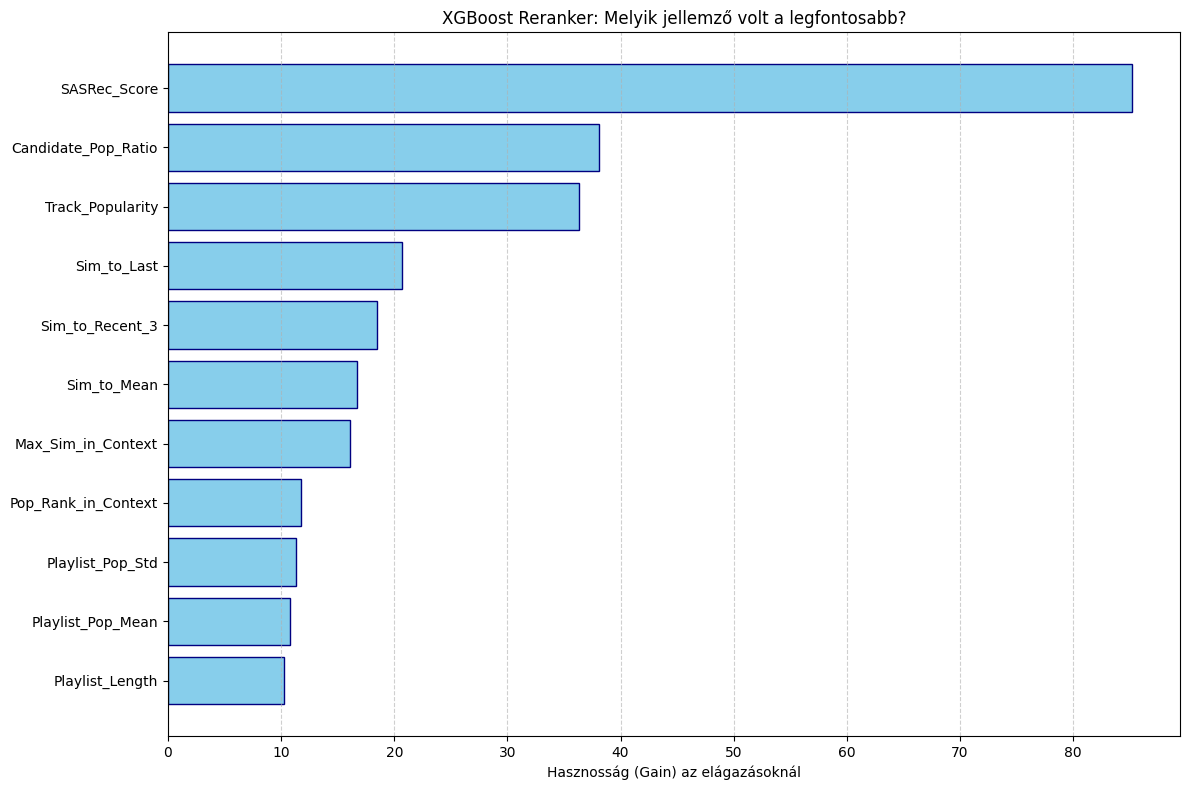

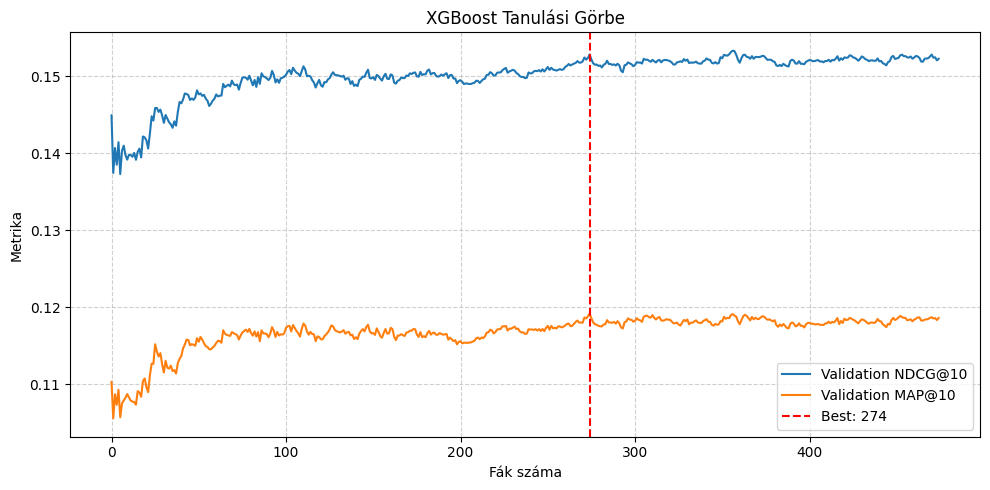

🏆 Legjobb iteráció: 274
🏆 Legjobb NDCG@10: 0.1533


In [4]:
import pandas as pd
import xgboost as xgb
import matplotlib.pyplot as plt

# ==========================================
# 1. ADATBETÖLTÉS ÉS RENDEZÉS
# ==========================================
print("📂 Parquet fájl betöltése...")
df = pd.read_parquet("../Models/xgboost_train_dataset_hybrid_filtered.parquet")
df = df.sort_values("Playlist_ID").reset_index(drop=True)

shuffled_parts = []
for pid, group in df.groupby("Playlist_ID"):
    shuffled_parts.append(group.sample(frac=1, random_state=42))
df = pd.concat(shuffled_parts).reset_index(drop=True)

# ==========================================
# 2. JELLEMZŐK DEFINIÁLÁSA
# ==========================================
# A Playlist_ID és Candidate_ID azonosítók, ezeket nem tanítjuk!
# BELEKERÜLTEK AZ ÚJ RELATÍV ÉS NORMALIZÁLT JELLEMZŐK:
features = [
    'Playlist_Length',
    #'SASRec_Rank',
    'SASRec_Score',
    'Sim_to_Last',
    'Sim_to_Mean',
    'Sim_to_Recent_3',
    'Max_Sim_in_Context',
    'Track_Popularity',
    'Playlist_Pop_Mean',
    'Playlist_Pop_Std',
    'Candidate_Pop_Ratio',
    'Pop_Rank_in_Context',
]

X = df[features]
y = df['Label']
groups = df['Playlist_ID']

# ==========================================
# 3. TRAIN-VAL SPLIT
# ==========================================
# Különválasztunk egy kis részt (pl. 5000 listát) ellenőrzésnek a tanítás alatt
total_playlists = groups.max()
train_idx = groups < (total_playlists - 5000)

X_train, y_train, qid_train = X[train_idx], y[train_idx], groups[train_idx]
X_val, y_val, qid_val = X[~train_idx], y[~train_idx], groups[~train_idx]

print(f"✅ Tanító halmaz: {len(X_train):,} sor")
print(f"✅ Validációs halmaz: {len(X_val):,} sor")

# ==========================================
# 4. MODELL DEFINÍCIÓ ÉS TANÍTÁS
# ==========================================
print("\n🚀 XGBoost tanítás indítása...")

ranker = xgb.XGBRanker(
    objective='rank:ndcg',       # ÚJ: Próbáld ki a Pairwise rangsorolást! (vagy hagyd rank:ndcg-n)
    n_estimators=2000,               # ÚJ: Felemelve 2000-re, az Early Stopping majd megállítja!
    learning_rate=0.05,              
    max_depth=6,                     
    subsample=0.8,                   
    colsample_bytree=0.8,            
    min_child_weight=10,              
    tree_method='hist',              
    random_state=42,
    # ÚJ: Több metrika figyelése! Az első metrika alapján fog működni az early_stopping.
    eval_metric=['ndcg@10', 'map@10'], 
    early_stopping_rounds=200        
)

# Tanítás monitoringgal
eval_result = ranker.fit(
    X_train, y_train,
    qid=qid_train,
    eval_set=[(X_val, y_val)], # ÚJ: A Train-t is betesszük, hogy lássuk az Overfittinget!
    eval_qid=[qid_val],
    verbose=50 # ÚJ: Elég 50 fánként kiírni, ha 2000 a max
)

# ==========================================
# 5. MENTÉS ÉS VIZUALIZÁCIÓ
# ==========================================
ranker.save_model("../Models/xgboost_reranker_final_hybrid_v3.json")
print("\n💾 Modell sikeresen elmentve!")

print("\n📊 Jellemzők fontosságának (Feature Importance) kirajzolása...")
importance = ranker.get_booster().get_score(importance_type='gain')
sorted_importance = sorted(importance.items(), key=lambda x: x[1], reverse=True)
labels, values = zip(*sorted_importance)

plt.figure(figsize=(12, 8))
plt.barh(labels[::-1], values[::-1], color='skyblue', edgecolor='navy')
plt.xlabel("Hasznosság (Gain) az elágazásoknál")
plt.title("XGBoost Reranker: Melyik jellemző volt a legfontosabb?")
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

results = ranker.evals_result()
epochs = len(results['validation_0']['ndcg@10'])

plt.figure(figsize=(10, 5))
plt.plot(results['validation_0']['ndcg@10'], label='Validation NDCG@10')
plt.plot(results['validation_0']['map@10'],  label='Validation MAP@10')
plt.axvline(x=ranker.best_iteration, color='red', linestyle='--', label=f'Best: {ranker.best_iteration}')
plt.legend()
plt.title('XGBoost Tanulási Görbe')
plt.xlabel('Fák száma')
plt.ylabel('Metrika')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

print(f"🏆 Legjobb iteráció: {ranker.best_iteration}")
print(f"🏆 Legjobb NDCG@10: {max(results['validation_0']['ndcg@10']):.4f}")

## Kiértékelés

In [5]:
import pandas as pd
import numpy as np
import xgboost as xgb

df_test = pd.read_parquet("../Models/xgboost_test_dataset_hybrid.parquet")

features = [
    'Playlist_Length',
    #'SASRec_Rank',
    'SASRec_Score',
    'Sim_to_Last',
    'Sim_to_Mean',
    'Sim_to_Recent_3',
    'Max_Sim_in_Context',
    'Track_Popularity',
    'Playlist_Pop_Mean',
    'Playlist_Pop_Std',
    'Candidate_Pop_Ratio',
    'Pop_Rank_in_Context',
]

ranker = xgb.XGBRanker()
ranker.load_model("../Models/xgboost_reranker_final_hybrid_v3.json")

df_test['XGB_Score'] = ranker.predict(df_test[features])
df_test['XGB_Rank'] = df_test.groupby('Playlist_ID')['XGB_Score'].rank(
    ascending=False, method='first'
).astype(int)

def calculate_metrics(df, rank_col, k_list):
    hits_df = df[df['Label'] == 1].copy()
    pos_ranks = hits_df[rank_col].values
    total_queries = df['Playlist_ID'].nunique()
    
    results = []
    for k in k_list:
        hr    = (pos_ranks <= k).sum() / total_queries
        ndcg  = np.sum([1/np.log2(r+1) if r <= k else 0 for r in pos_ranks]) / total_queries
        map_k = np.sum([1/r if r <= k else 0 for r in pos_ranks]) / total_queries
        results.append({'k': k, 'HR': hr, 'NDCG': ndcg, 'MAP': map_k})
    
    def get_click(r):
        if r > 500 or pd.isna(r): return 51
        return (int(r) - 1) // 10
    avg_clicks = hits_df[rank_col].apply(get_click).sum()
    missing = total_queries - len(hits_df)
    avg_clicks = (avg_clicks + missing * 51) / total_queries
    
    return pd.DataFrame(results), avg_clicks

K_VALUES = [1, 5, 10, 20, 50, 100, 200, 500]
sas_m, sas_c = calculate_metrics(df_test, 'SASRec_Rank', K_VALUES)
xgb_m, xgb_c = calculate_metrics(df_test, 'XGB_Rank',   K_VALUES)

summary = sas_m.set_index('k').join(xgb_m.set_index('k'), lsuffix='_SAS', rsuffix='_XGB')
for m in ['HR', 'NDCG', 'MAP']:
    summary[f'{m}_imp%'] = (summary[f'{m}_XGB'] - summary[f'{m}_SAS']) / summary[f'{m}_SAS'] * 100

print("\n" + "="*70)
print("🏆 EREDMÉNYEK")
print("="*70)
pd.options.display.float_format = '{:.4f}'.format
cols = [c for m in ['HR','NDCG','MAP'] for c in [f'{m}_SAS', f'{m}_XGB', f'{m}_imp%']]
print(summary[cols].T.to_string())
print(f"\n🖱️ Clicks SASRec:  {sas_c:.4f}")
print(f"🖱️ Clicks XGBoost: {xgb_c:.4f}")
print(f"🚀 Clicks javulás: {(xgb_c - sas_c)/sas_c*100:.2f}%")


🏆 EREDMÉNYEK
k             1       5       10      20      50      100     200     500
HR_SAS     0.0221  0.0624  0.0938  0.1319  0.2005  0.2675  0.3443  0.4578
HR_XGB     0.0304  0.0796  0.1164  0.1628  0.2441  0.3191  0.3960  0.4578
HR_imp%   37.6256 27.5873 24.1424 23.4557 21.7501 19.2703 15.0321  0.0000
NDCG_SAS   0.0221  0.0425  0.0526  0.0622  0.0758  0.0866  0.0973  0.1110
NDCG_XGB   0.0304  0.0552  0.0671  0.0788  0.0949  0.1070  0.1178  0.1254
NDCG_imp% 37.6256 29.9829 27.5975 26.6939 25.2265 23.5593 21.0260 12.9279
MAP_SAS    0.0221  0.0360  0.0401  0.0427  0.0449  0.0458  0.0464  0.0467
MAP_XGB    0.0304  0.0473  0.0521  0.0553  0.0579  0.0589  0.0595  0.0597
MAP_imp%  37.6256 31.3716 29.9862 29.4791 28.9520 28.6040 28.2877 27.7438

🖱️ Clicks SASRec:  33.0818
🖱️ Clicks XGBoost: 31.3003
🚀 Clicks javulás: -5.39%


# Mel+Chroma+Tempo zenei attribútumok

In [1]:
import random
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers
import faiss
import h5py
from gensim.models import Word2Vec
from tqdm.auto import tqdm
import pyarrow as pa
import pyarrow.parquet as pq
import gc

# ==========================================
# 1. ÚTVONALAK ÉS PARAMÉTEREK
# ==========================================
VAL_DATA_PATH   = "../Models/val_pids.npy"
W2V_MODEL_PATH  = "../Models/song2vec.model"
W2V_MATRIX_PATH = "../Models/hybrid_embedding_matrix.npy"
H5_FILE         = "../Dataset/spotify_dataset_compressed.h5"
WEIGHTS_PATH    = "../Models/best_sasrec_large_hard_w2v_only.weights.h5"
OUTPUT_PARQUET  = "../Models/xgboost_train_dataset_hybrid_v2.parquet"

MAX_LEN = 50
BATCH_SIZE = 256
TOP_K = 500  # Változatlanul hagyva kérés szerint

# ==========================================
# 2. METAADATOK ÉS SZÓTÁR ELŐTÖLTÉSE
# ==========================================
print("📖 Word2Vec szótár és beágyazások betöltése...")
w2v_model = Word2Vec.load(W2V_MODEL_PATH)
uri_to_id = w2v_model.wv.key_to_index

embeddings = np.load(W2V_MATRIX_PATH).astype('float32')
vocab_size, D_MODEL = embeddings.shape

embeddings_norm = embeddings.copy()
faiss.normalize_L2(embeddings_norm)

print("📈 Dalok népszerűségének kiszámítása a Train halmazból...")
track_popularity = np.zeros(vocab_size, dtype=int)
train_playlists = np.load("../Models/train_pids.npy", allow_pickle=True)
for pl in train_playlists:
    for track_id in pl:
        if track_id < vocab_size:
            track_popularity[track_id] += 1

track_global_entropy = np.full(vocab_size, np.nan, dtype=np.float32)
track_max_local_entropy = np.full(vocab_size, np.nan, dtype=np.float32)
track_is_cnn = np.zeros(vocab_size, dtype=int)

# ÚJ: Előadó és Album szótárak
track_to_artist = {}
track_to_album = {}

print("🧮 HDF5 metaadatok beolvasása...")
with h5py.File(H5_FILE, "r") as hf:
    # Attól függően, hogy a compressed.h5-ben pontosan mi az útvonal, 
    # itt a te eredeti útvonalaidat (ml/track_uri és tracks/...) használjuk.
    # Ha az új HDF5-öt használod, módosítsd "tracks/track_uri"-ra.
    try:
        track_uris_hdf5 = hf["ml/track_uri"][:]
    except KeyError:
        track_uris_hdf5 = hf["tracks/track_uri"][:]
        
    entropy_global_data = hf["features/markov_entropy_global"][:]
    entropy_local_data = hf["features/markov_entropy_local"][:]
    
    # ÚJ: Előadó és Album URI-k kinyerése
    artist_uris_hdf5 = hf["tracks/artist_uri"][:]
    album_uris_hdf5 = hf["tracks/album_uri"][:]

    # Szöveg dekódolás (ha bytes formátumban lenne)
    def decode_if_bytes(data):
        if isinstance(data[0], bytes):
            return [x.decode('utf-8') for x in data]
        return data

    track_uris_hdf5 = decode_if_bytes(track_uris_hdf5)
    artist_uris_hdf5 = decode_if_bytes(artist_uris_hdf5)
    album_uris_hdf5 = decode_if_bytes(album_uris_hdf5)

    for hdf5_idx, uri in enumerate(tqdm(track_uris_hdf5, desc="Mapping")):
        if uri in uri_to_id:
            sasrec_id = uri_to_id[uri]
            if sasrec_id < vocab_size:
                track_global_entropy[sasrec_id] = entropy_global_data[hdf5_idx][0]
                track_max_local_entropy[sasrec_id] = np.max(entropy_local_data[hdf5_idx])
                track_is_cnn[sasrec_id] = 1
                
                # ÚJ: Előadó és album hozzárendelése a SASRec ID-hoz
                track_to_artist[sasrec_id] = artist_uris_hdf5[hdf5_idx]
                track_to_album[sasrec_id] = album_uris_hdf5[hdf5_idx]

print(f"❄️ Cold Start szimulálva: {(track_is_cnn == 1).sum():,} dal népszerűsége lenullázva.")
track_popularity[track_is_cnn == 1] = 0

# ==========================================
# 3. SASREC MODELL (INFERENCIA VERZIÓ)
# ==========================================
print("🏗️ SASRec Modell inicializálása...")
def create_inference_model(vocab_size, init_weights):
    seq_inputs = layers.Input(shape=(MAX_LEN,), name="seq_inputs")
    item_embedding = layers.Embedding(
        vocab_size, D_MODEL, mask_zero=True,
        embeddings_initializer=tf.keras.initializers.Constant(init_weights),
        trainable=True, name="w2v_embedding"
    )
    pos_embedding = layers.Embedding(MAX_LEN, D_MODEL, name="pos_embedding")
    x = item_embedding(seq_inputs)
    x += pos_embedding(tf.range(MAX_LEN)[tf.newaxis, :])
    for _ in range(3):
        attn = layers.MultiHeadAttention(num_heads=8, key_dim=D_MODEL//8)(x, x, use_causal_mask=True)
        x = layers.LayerNormalization()(x + layers.Dropout(0.2)(attn))
        ffn = layers.Dense(D_MODEL * 4, activation='relu')(x)
        ffn = layers.Dense(D_MODEL)(ffn)
        x = layers.LayerNormalization()(x + layers.Dropout(0.2)(ffn))
    seq_states = layers.Dense(D_MODEL, name="final_projection")(x)
    return tf.keras.Model(inputs=seq_inputs, outputs=seq_states)

inference_model = create_inference_model(vocab_size, embeddings)
inference_model.load_weights(WEIGHTS_PATH)

print("🔍 FAISS Index építése...")
updated_embeddings = inference_model.get_layer("w2v_embedding").get_weights()[0]
faiss_embeddings = updated_embeddings.copy().astype('float32')
faiss.normalize_L2(faiss_embeddings)
index = faiss.IndexFlatIP(D_MODEL)
index.add(faiss_embeddings)

# ==========================================
# 4. KÖTEGELT TÁBLÁZATGENERÁLÁS
# ==========================================
print("🚀 Táblázat generálása és folyamatos lemezre írása...")
val_playlists = np.load(VAL_DATA_PATH, allow_pickle=True)
val_playlists = np.array([[t for t in pl if t != 0] for pl in val_playlists], dtype=object)

dataset_rows = []
global_playlist_id = 0
writer = None

for i in tqdm(range(0, len(val_playlists), BATCH_SIZE), desc="SASRec Predikciók"):
    batch_lists = val_playlists[i : i + BATCH_SIZE]
    batch_padded, targets, valid_contexts = [], [], []

    for pl in batch_lists:
        if len(pl) < 2: continue
        targets.append(pl[-1])
        context = pl[:-1]
        valid_contexts.append(context)
        input_seq = context[-MAX_LEN:]
        batch_padded.append([0] * (MAX_LEN - len(input_seq)) + list(input_seq))

    if not batch_padded: continue

    pred_vectors = inference_model.predict_on_batch(np.array(batch_padded))
    target_pred_vectors = pred_vectors[:, -1, :].astype('float32')
    faiss.normalize_L2(target_pred_vectors)
    raw_scores, raw_indices = index.search(target_pred_vectors, TOP_K + MAX_LEN)

    for b_idx in range(len(valid_contexts)):
        context = valid_contexts[b_idx]
        actual_target = targets[b_idx]
        last_track_vec = embeddings_norm[context[-1]]

        playlist_mean_vec = np.mean(embeddings_norm[context], axis=0)
        playlist_mean_vec /= (np.linalg.norm(playlist_mean_vec) + 1e-8)

        context_pops = [track_popularity[t] for t in context]
        playlist_pop_mean = float(np.mean(context_pops))
        playlist_pop_std = float(np.std(context_pops))

        context_entropies = [track_global_entropy[t] for t in context
                             if not np.isnan(track_global_entropy[t])]
        playlist_entropy_mean = float(np.mean(context_entropies)) \
                                if len(context_entropies) > 0 else 0.0

        context_local_entropies = [track_max_local_entropy[t] for t in context
                                   if not np.isnan(track_max_local_entropy[t])]
        playlist_local_entropy_mean = float(np.mean(context_local_entropies)) \
                                      if len(context_local_entropies) > 0 else 0.0

        recent_3 = context[-3:]
        recent_3_vecs = embeddings_norm[recent_3] 
        context_pops_arr = np.array(context_pops)
        context_vecs = embeddings_norm[list(context)] 

        # ÚJ: Playlist szintű metadata kinyerése
        context_artists = [track_to_artist.get(t, "") for t in context]
        context_albums = [track_to_album.get(t, "") for t in context]
        recent_3_artists = context_artists[-3:]

        pos_samples, neg_samples = [], []
        current_rank = 1

        for score, cand_id in zip(raw_scores[b_idx], raw_indices[b_idx]):
            if cand_id in context or cand_id == 0: continue
            if len(pos_samples) + len(neg_samples) >= TOP_K: break

            is_target = 1 if cand_id == actual_target else 0
            cand_vec = embeddings_norm[cand_id]
            cand_pop = track_popularity[cand_id]
            cand_entropy = track_global_entropy[cand_id]
            cand_local_entropy = track_max_local_entropy[cand_id]

            pop_ratio = cand_pop / (playlist_pop_mean + 1.0)
            entropy_diff = abs(cand_entropy - playlist_entropy_mean) \
                           if not np.isnan(cand_entropy) else -1.0
            local_entropy_diff = abs(cand_local_entropy - playlist_local_entropy_mean) \
                                 if not np.isnan(cand_local_entropy) else -1.0

            sim_to_recent_3 = float(np.mean(recent_3_vecs @ cand_vec))
            max_sim_in_context = float(np.max(context_vecs @ cand_vec))
            pop_rank_in_context = float(np.mean(context_pops_arr > cand_pop))

            # ÚJ: Előadó és Album feature-ök kiszámítása a jelöltre
            cand_artist = track_to_artist.get(cand_id, "")
            cand_album = track_to_album.get(cand_id, "")
            
            # Van-e egyezés (és nem üres string)
            artist_in_recent_3 = 1 if (cand_artist and cand_artist in recent_3_artists) else 0
            artist_match_total = context_artists.count(cand_artist) if cand_artist else 0
            album_match_total = context_albums.count(cand_album) if cand_album else 0

            row = {
                "Playlist_ID": global_playlist_id,
                "Candidate_ID": cand_id,
                "Playlist_Length": len(context),
                "SASRec_Rank": current_rank,
                "SASRec_Score": float(score),
                "Sim_to_Last": float(np.dot(last_track_vec, cand_vec)),
                "Sim_to_Mean": float(np.dot(playlist_mean_vec, cand_vec)),
                "Sim_to_Recent_3": sim_to_recent_3,
                "Max_Sim_in_Context": max_sim_in_context,
                "Track_Popularity": cand_pop,
                "Global_Entropy": cand_entropy,
                "Max_Local_Entropy": cand_local_entropy,
                "Playlist_Pop_Mean": playlist_pop_mean,
                "Playlist_Pop_Std": playlist_pop_std,
                "Candidate_Pop_Ratio": float(pop_ratio),
                "Pop_Rank_in_Context": pop_rank_in_context,
                "Entropy_Diff": float(entropy_diff),
                "Local_Entropy_Diff": float(local_entropy_diff),
                "Artist_in_Recent_3": int(artist_in_recent_3),   # ÚJ
                "Artist_Match_Total": int(artist_match_total),   # ÚJ
                "Album_Match_Total": int(album_match_total),     # ÚJ
                "Label": is_target
            }

            if is_target:
                pos_samples.append(row)
            else:
                neg_samples.append(row)
            current_rank += 1

        dataset_rows.extend(pos_samples)
        dataset_rows.extend(neg_samples)
        global_playlist_id += 1

    # --- FLUSH ---
    if len(dataset_rows) >= 500000:
        df_chunk = pd.DataFrame(dataset_rows)
        table = pa.Table.from_pandas(df_chunk)
        if writer is None:
            writer = pq.ParquetWriter(OUTPUT_PARQUET, table.schema)
        writer.write_table(table)
        dataset_rows.clear()
        del df_chunk, table
        gc.collect()

# ==========================================
# 5. MARADÉK KIÍRÁSA ÉS FÁJL LEZÁRÁSA
# ==========================================
print("💾 Maradék adatok mentése és fájl lezárása...")
if len(dataset_rows) > 0:
    df_chunk = pd.DataFrame(dataset_rows)
    table = pa.Table.from_pandas(df_chunk)
    if writer is None:
        writer = pq.ParquetWriter(OUTPUT_PARQUET, table.schema)
    writer.write_table(table)

if writer is not None:
    writer.close()

# ==========================================
# 6. SZŰRÉS
# ==========================================
print("🧹 Pozitív nélküli listák szűrése...")
df = pd.read_parquet(OUTPUT_PARQUET)
lists_with_pos = df[df['Label'] == 1]['Playlist_ID'].unique()
df_filtered = df[df['Playlist_ID'].isin(lists_with_pos)].reset_index(drop=True)
df_filtered.to_parquet(OUTPUT_PARQUET.replace('.parquet', '_filtered.parquet'), index=False)

print(f"🎉 KÉSZ! Generált sorok: {len(df):,} → Szűrt sorok: {len(df_filtered):,}")
del df, df_filtered
gc.collect()

📖 Word2Vec szótár és beágyazások betöltése...
📈 Dalok népszerűségének kiszámítása a Train halmazból...
🧮 HDF5 metaadatok beolvasása...


Mapping:   0%|          | 0/27052 [00:00<?, ?it/s]

❄️ Cold Start szimulálva: 25,511 dal népszerűsége lenullázva.
🏗️ SASRec Modell inicializálása...
🔍 FAISS Index építése...
🚀 Táblázat generálása és folyamatos lemezre írása...


SASRec Predikciók:   0%|          | 0/388 [00:00<?, ?it/s]

💾 Maradék adatok mentése és fájl lezárása...
🧹 Pozitív nélküli listák szűrése...
🎉 KÉSZ! Generált sorok: 49,353,010 → Szűrt sorok: 22,508,195


19

## Tanítás

📂 Parquet fájl betöltése...
✅ Tanító halmaz: 21,366,396 sor
✅ Validációs halmaz: 1,141,799 sor

🚀 XGBoost tanítás indítása...
[0]	validation_0-ndcg@10:0.14231	validation_0-map@10:0.10925
[50]	validation_0-ndcg@10:0.14398	validation_0-map@10:0.11191
[100]	validation_0-ndcg@10:0.14605	validation_0-map@10:0.11386
[150]	validation_0-ndcg@10:0.14815	validation_0-map@10:0.11513
[200]	validation_0-ndcg@10:0.14890	validation_0-map@10:0.11538
[250]	validation_0-ndcg@10:0.14873	validation_0-map@10:0.11487
[300]	validation_0-ndcg@10:0.14838	validation_0-map@10:0.11464
[350]	validation_0-ndcg@10:0.14718	validation_0-map@10:0.11396
[355]	validation_0-ndcg@10:0.14731	validation_0-map@10:0.11425

💾 Modell sikeresen elmentve!

📊 Jellemzők fontosságának (Feature Importance) kirajzolása...


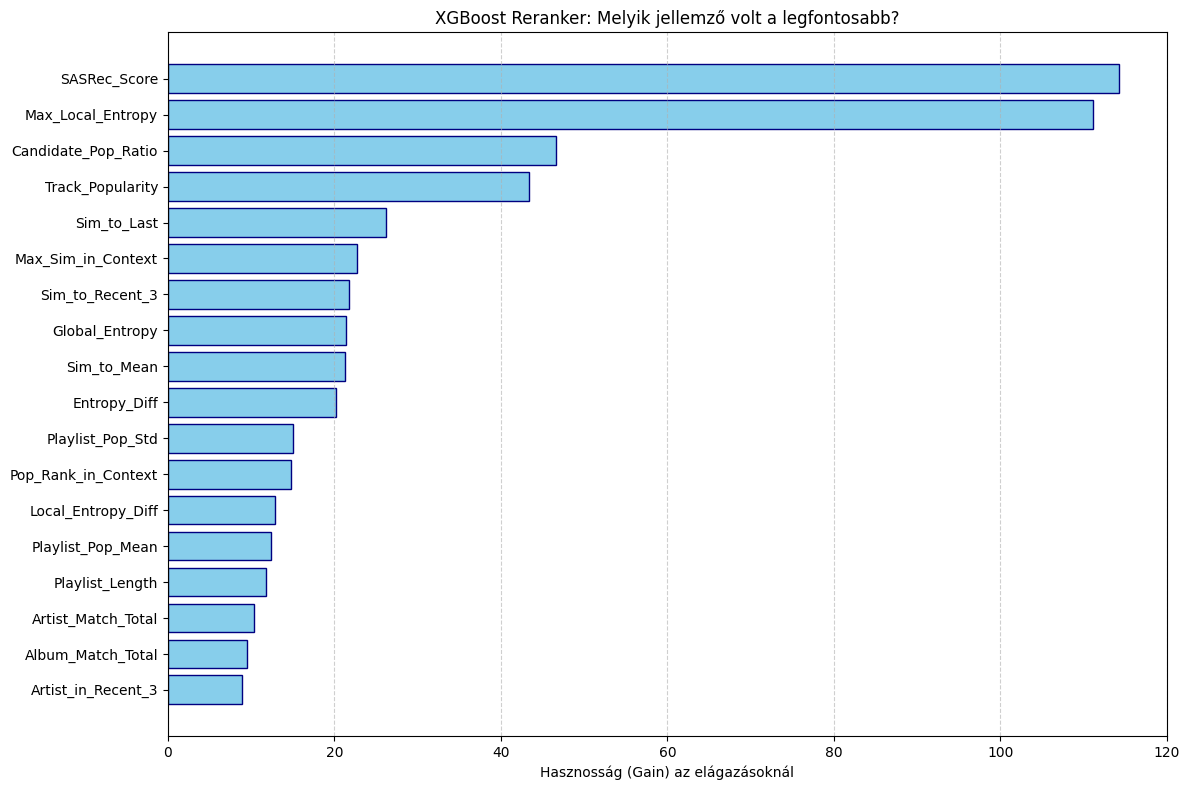


📈 Tanulási görbe...


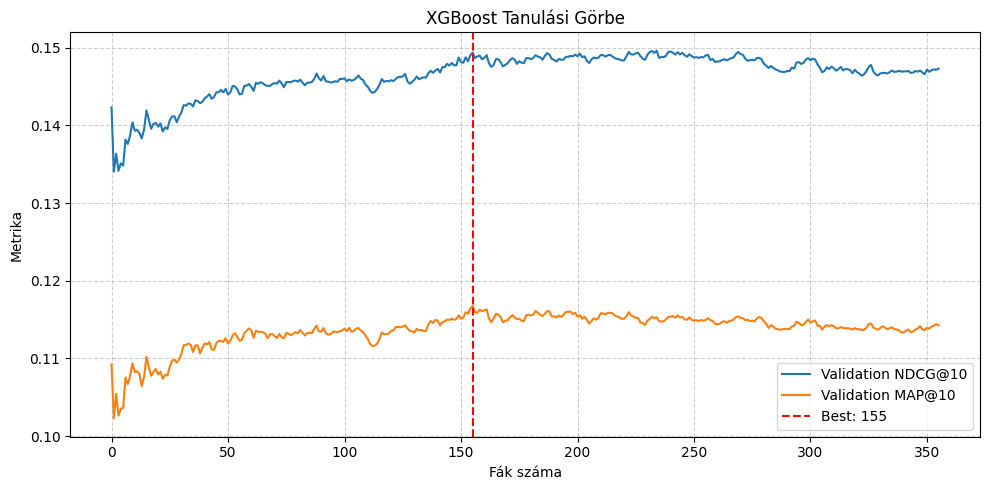

🏆 Legjobb iteráció: 155
🏆 Legjobb NDCG@10: 0.1496


In [2]:
import pandas as pd
import xgboost as xgb
import matplotlib.pyplot as plt

# ==========================================
# 1. ADATBETÖLTÉS ÉS RENDEZÉS
# ==========================================
print("📂 Parquet fájl betöltése...")
df = pd.read_parquet("../Models/xgboost_train_dataset_hybrid_v2_filtered.parquet")  # ← filtered
df = df.sort_values("Playlist_ID").reset_index(drop=True)

# Listán belüli shuffle — pozitív ne legyen mindig elöl
shuffled_parts = []
for pid, group in df.groupby("Playlist_ID"):
    shuffled_parts.append(group.sample(frac=1, random_state=42))
df = pd.concat(shuffled_parts).reset_index(drop=True)

# ==========================================
# 2. JELLEMZŐK DEFINIÁLÁSA
# ==========================================
features = [
    'Playlist_Length',
    #'SASRec_Rank',
    'SASRec_Score',
    'Sim_to_Last',
    'Sim_to_Mean',
    'Sim_to_Recent_3',       # ← ÚJ
    'Max_Sim_in_Context',    # ← ÚJ
    'Track_Popularity',
    'Global_Entropy',
    'Max_Local_Entropy',
    'Playlist_Pop_Mean',
    'Playlist_Pop_Std',
    'Candidate_Pop_Ratio',
    'Pop_Rank_in_Context',   # ← ÚJ
    'Entropy_Diff',
    'Local_Entropy_Diff',
    "Artist_in_Recent_3",
    "Artist_Match_Total",
    "Album_Match_Total"
]

X = df[features]
y = df['Label']
groups = df['Playlist_ID']

# ==========================================
# 3. TRAIN-VAL SPLIT
# ==========================================
total_playlists = groups.max()
train_idx = groups < (total_playlists - 5000)

X_train, y_train, qid_train = X[train_idx], y[train_idx], groups[train_idx]
X_val, y_val, qid_val = X[~train_idx], y[~train_idx], groups[~train_idx]

print(f"✅ Tanító halmaz: {len(X_train):,} sor")
print(f"✅ Validációs halmaz: {len(X_val):,} sor")

# ==========================================
# 4. MODELL DEFINÍCIÓ ÉS TANÍTÁS
# ==========================================
print("\n🚀 XGBoost tanítás indítása...")

ranker = xgb.XGBRanker(
    objective='rank:ndcg',
    n_estimators=2000,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=10,
    tree_method='hist',
    random_state=42,
    eval_metric=['ndcg@10', 'map@10'],
    early_stopping_rounds=200
)

ranker.fit(
    X_train, y_train,
    qid=qid_train,
    eval_set=[(X_val, y_val)],
    eval_qid=[qid_val],
    verbose=50
)

# ==========================================
# 5. MENTÉS ÉS VIZUALIZÁCIÓ
# ==========================================
ranker.save_model("../Models/xgboost_reranker_final_hybrid_v4.json")
print("\n💾 Modell sikeresen elmentve!")

print("\n📊 Jellemzők fontosságának (Feature Importance) kirajzolása...")
importance = ranker.get_booster().get_score(importance_type='gain')
sorted_importance = sorted(importance.items(), key=lambda x: x[1], reverse=True)
labels, values = zip(*sorted_importance)

plt.figure(figsize=(12, 8))
plt.barh(labels[::-1], values[::-1], color='skyblue', edgecolor='navy')
plt.xlabel("Hasznosság (Gain) az elágazásoknál")
plt.title("XGBoost Reranker: Melyik jellemző volt a legfontosabb?")
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

print("\n📈 Tanulási görbe...")
results = ranker.evals_result()
plt.figure(figsize=(10, 5))
plt.plot(results['validation_0']['ndcg@10'], label='Validation NDCG@10')
plt.plot(results['validation_0']['map@10'],  label='Validation MAP@10')
plt.axvline(x=ranker.best_iteration, color='red', linestyle='--',
            label=f'Best: {ranker.best_iteration}')
plt.legend()
plt.title('XGBoost Tanulási Görbe')
plt.xlabel('Fák száma')
plt.ylabel('Metrika')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

print(f"🏆 Legjobb iteráció: {ranker.best_iteration}")
print(f"🏆 Legjobb NDCG@10: {max(results['validation_0']['ndcg@10']):.4f}")

In [3]:
import random
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers
import faiss
import h5py
from gensim.models import Word2Vec
from tqdm.auto import tqdm
import pyarrow as pa
import pyarrow.parquet as pq
import gc

# ==========================================
# 1. ÚTVONALAK ÉS PARAMÉTEREK
# ==========================================
VAL_DATA_PATH   = "../Models/test_pids.npy"
W2V_MODEL_PATH  = "../Models/song2vec.model"
W2V_MATRIX_PATH = "../Models/hybrid_embedding_matrix.npy"
H5_FILE         = "../Dataset/spotify_dataset_compressed.h5"
WEIGHTS_PATH    = "../Models/best_sasrec_large_hard_w2v_only.weights.h5"
OUTPUT_PARQUET  = "../Models/xgboost_test_dataset_hybrid_v3.parquet"

MAX_LEN = 50
BATCH_SIZE = 256
TOP_K = 500  # Változatlanul hagyva kérés szerint

# ==========================================
# 2. METAADATOK ÉS SZÓTÁR ELŐTÖLTÉSE
# ==========================================
print("📖 Word2Vec szótár és beágyazások betöltése...")
w2v_model = Word2Vec.load(W2V_MODEL_PATH)
uri_to_id = w2v_model.wv.key_to_index

embeddings = np.load(W2V_MATRIX_PATH).astype('float32')
vocab_size, D_MODEL = embeddings.shape

embeddings_norm = embeddings.copy()
faiss.normalize_L2(embeddings_norm)

print("📈 Dalok népszerűségének kiszámítása a Train halmazból...")
track_popularity = np.zeros(vocab_size, dtype=int)
train_playlists = np.load("../Models/train_pids.npy", allow_pickle=True)
for pl in train_playlists:
    for track_id in pl:
        if track_id < vocab_size:
            track_popularity[track_id] += 1

track_global_entropy = np.full(vocab_size, np.nan, dtype=np.float32)
track_max_local_entropy = np.full(vocab_size, np.nan, dtype=np.float32)
track_is_cnn = np.zeros(vocab_size, dtype=int)

# ÚJ: Előadó és Album szótárak
track_to_artist = {}
track_to_album = {}

print("🧮 HDF5 metaadatok beolvasása...")
with h5py.File(H5_FILE, "r") as hf:
    # Attól függően, hogy a compressed.h5-ben pontosan mi az útvonal, 
    # itt a te eredeti útvonalaidat (ml/track_uri és tracks/...) használjuk.
    # Ha az új HDF5-öt használod, módosítsd "tracks/track_uri"-ra.
    try:
        track_uris_hdf5 = hf["ml/track_uri"][:]
    except KeyError:
        track_uris_hdf5 = hf["tracks/track_uri"][:]
        
    entropy_global_data = hf["features/markov_entropy_global"][:]
    entropy_local_data = hf["features/markov_entropy_local"][:]
    
    # ÚJ: Előadó és Album URI-k kinyerése
    artist_uris_hdf5 = hf["tracks/artist_uri"][:]
    album_uris_hdf5 = hf["tracks/album_uri"][:]

    # Szöveg dekódolás (ha bytes formátumban lenne)
    def decode_if_bytes(data):
        if isinstance(data[0], bytes):
            return [x.decode('utf-8') for x in data]
        return data

    track_uris_hdf5 = decode_if_bytes(track_uris_hdf5)
    artist_uris_hdf5 = decode_if_bytes(artist_uris_hdf5)
    album_uris_hdf5 = decode_if_bytes(album_uris_hdf5)

    for hdf5_idx, uri in enumerate(tqdm(track_uris_hdf5, desc="Mapping")):
        if uri in uri_to_id:
            sasrec_id = uri_to_id[uri]
            if sasrec_id < vocab_size:
                track_global_entropy[sasrec_id] = entropy_global_data[hdf5_idx][0]
                track_max_local_entropy[sasrec_id] = np.max(entropy_local_data[hdf5_idx])
                track_is_cnn[sasrec_id] = 1
                
                # ÚJ: Előadó és album hozzárendelése a SASRec ID-hoz
                track_to_artist[sasrec_id] = artist_uris_hdf5[hdf5_idx]
                track_to_album[sasrec_id] = album_uris_hdf5[hdf5_idx]

print(f"❄️ Cold Start szimulálva: {(track_is_cnn == 1).sum():,} dal népszerűsége lenullázva.")
track_popularity[track_is_cnn == 1] = 0

# ==========================================
# 3. SASREC MODELL (INFERENCIA VERZIÓ)
# ==========================================
print("🏗️ SASRec Modell inicializálása...")
def create_inference_model(vocab_size, init_weights):
    seq_inputs = layers.Input(shape=(MAX_LEN,), name="seq_inputs")
    item_embedding = layers.Embedding(
        vocab_size, D_MODEL, mask_zero=True,
        embeddings_initializer=tf.keras.initializers.Constant(init_weights),
        trainable=True, name="w2v_embedding"
    )
    pos_embedding = layers.Embedding(MAX_LEN, D_MODEL, name="pos_embedding")
    x = item_embedding(seq_inputs)
    x += pos_embedding(tf.range(MAX_LEN)[tf.newaxis, :])
    for _ in range(3):
        attn = layers.MultiHeadAttention(num_heads=8, key_dim=D_MODEL//8)(x, x, use_causal_mask=True)
        x = layers.LayerNormalization()(x + layers.Dropout(0.2)(attn))
        ffn = layers.Dense(D_MODEL * 4, activation='relu')(x)
        ffn = layers.Dense(D_MODEL)(ffn)
        x = layers.LayerNormalization()(x + layers.Dropout(0.2)(ffn))
    seq_states = layers.Dense(D_MODEL, name="final_projection")(x)
    return tf.keras.Model(inputs=seq_inputs, outputs=seq_states)

inference_model = create_inference_model(vocab_size, embeddings)
inference_model.load_weights(WEIGHTS_PATH)

print("🔍 FAISS Index építése...")
updated_embeddings = inference_model.get_layer("w2v_embedding").get_weights()[0]
faiss_embeddings = updated_embeddings.copy().astype('float32')
faiss.normalize_L2(faiss_embeddings)
index = faiss.IndexFlatIP(D_MODEL)
index.add(faiss_embeddings)

# ==========================================
# 4. KÖTEGELT TÁBLÁZATGENERÁLÁS
# ==========================================
print("🚀 Táblázat generálása és folyamatos lemezre írása...")
val_playlists = np.load(VAL_DATA_PATH, allow_pickle=True)
val_playlists = np.array([[t for t in pl if t != 0] for pl in val_playlists], dtype=object)

dataset_rows = []
global_playlist_id = 0
writer = None

for i in tqdm(range(0, len(val_playlists), BATCH_SIZE), desc="SASRec Predikciók"):
    batch_lists = val_playlists[i : i + BATCH_SIZE]
    batch_padded, targets, valid_contexts = [], [], []

    for pl in batch_lists:
        if len(pl) < 2: continue
        targets.append(pl[-1])
        context = pl[:-1]
        valid_contexts.append(context)
        input_seq = context[-MAX_LEN:]
        batch_padded.append([0] * (MAX_LEN - len(input_seq)) + list(input_seq))

    if not batch_padded: continue

    pred_vectors = inference_model.predict_on_batch(np.array(batch_padded))
    target_pred_vectors = pred_vectors[:, -1, :].astype('float32')
    faiss.normalize_L2(target_pred_vectors)
    raw_scores, raw_indices = index.search(target_pred_vectors, TOP_K + MAX_LEN)

    for b_idx in range(len(valid_contexts)):
        context = valid_contexts[b_idx]
        actual_target = targets[b_idx]
        last_track_vec = embeddings_norm[context[-1]]

        playlist_mean_vec = np.mean(embeddings_norm[context], axis=0)
        playlist_mean_vec /= (np.linalg.norm(playlist_mean_vec) + 1e-8)

        context_pops = [track_popularity[t] for t in context]
        playlist_pop_mean = float(np.mean(context_pops))
        playlist_pop_std = float(np.std(context_pops))

        context_entropies = [track_global_entropy[t] for t in context
                             if not np.isnan(track_global_entropy[t])]
        playlist_entropy_mean = float(np.mean(context_entropies)) \
                                if len(context_entropies) > 0 else 0.0

        context_local_entropies = [track_max_local_entropy[t] for t in context
                                   if not np.isnan(track_max_local_entropy[t])]
        playlist_local_entropy_mean = float(np.mean(context_local_entropies)) \
                                      if len(context_local_entropies) > 0 else 0.0

        recent_3 = context[-3:]
        recent_3_vecs = embeddings_norm[recent_3] 
        context_pops_arr = np.array(context_pops)
        context_vecs = embeddings_norm[list(context)] 

        # ÚJ: Playlist szintű metadata kinyerése
        context_artists = [track_to_artist.get(t, "") for t in context]
        context_albums = [track_to_album.get(t, "") for t in context]
        recent_3_artists = context_artists[-3:]

        pos_samples, neg_samples = [], []
        current_rank = 1

        for score, cand_id in zip(raw_scores[b_idx], raw_indices[b_idx]):
            if cand_id in context or cand_id == 0: continue
            if len(pos_samples) + len(neg_samples) >= TOP_K: break

            is_target = 1 if cand_id == actual_target else 0
            cand_vec = embeddings_norm[cand_id]
            cand_pop = track_popularity[cand_id]
            cand_entropy = track_global_entropy[cand_id]
            cand_local_entropy = track_max_local_entropy[cand_id]

            pop_ratio = cand_pop / (playlist_pop_mean + 1.0)
            entropy_diff = abs(cand_entropy - playlist_entropy_mean) \
                           if not np.isnan(cand_entropy) else -1.0
            local_entropy_diff = abs(cand_local_entropy - playlist_local_entropy_mean) \
                                 if not np.isnan(cand_local_entropy) else -1.0

            sim_to_recent_3 = float(np.mean(recent_3_vecs @ cand_vec))
            max_sim_in_context = float(np.max(context_vecs @ cand_vec))
            pop_rank_in_context = float(np.mean(context_pops_arr > cand_pop))

            # ÚJ: Előadó és Album feature-ök kiszámítása a jelöltre
            cand_artist = track_to_artist.get(cand_id, "")
            cand_album = track_to_album.get(cand_id, "")
            
            # Van-e egyezés (és nem üres string)
            artist_in_recent_3 = 1 if (cand_artist and cand_artist in recent_3_artists) else 0
            artist_match_total = context_artists.count(cand_artist) if cand_artist else 0
            album_match_total = context_albums.count(cand_album) if cand_album else 0

            row = {
                "Playlist_ID": global_playlist_id,
                "Candidate_ID": cand_id,
                "Playlist_Length": len(context),
                "SASRec_Rank": current_rank,
                "SASRec_Score": float(score),
                "Sim_to_Last": float(np.dot(last_track_vec, cand_vec)),
                "Sim_to_Mean": float(np.dot(playlist_mean_vec, cand_vec)),
                "Sim_to_Recent_3": sim_to_recent_3,
                "Max_Sim_in_Context": max_sim_in_context,
                "Track_Popularity": cand_pop,
                "Global_Entropy": cand_entropy,
                "Max_Local_Entropy": cand_local_entropy,
                "Playlist_Pop_Mean": playlist_pop_mean,
                "Playlist_Pop_Std": playlist_pop_std,
                "Candidate_Pop_Ratio": float(pop_ratio),
                "Pop_Rank_in_Context": pop_rank_in_context,
                "Entropy_Diff": float(entropy_diff),
                "Local_Entropy_Diff": float(local_entropy_diff),
                "Artist_in_Recent_3": int(artist_in_recent_3),   # ÚJ
                "Artist_Match_Total": int(artist_match_total),   # ÚJ
                "Album_Match_Total": int(album_match_total),     # ÚJ
                "Label": is_target
            }

            if is_target:
                pos_samples.append(row)
            else:
                neg_samples.append(row)
            current_rank += 1

        dataset_rows.extend(pos_samples)
        dataset_rows.extend(neg_samples)
        global_playlist_id += 1

    # --- FLUSH ---
    if len(dataset_rows) >= 500000:
        df_chunk = pd.DataFrame(dataset_rows)
        table = pa.Table.from_pandas(df_chunk)
        if writer is None:
            writer = pq.ParquetWriter(OUTPUT_PARQUET, table.schema)
        writer.write_table(table)
        dataset_rows.clear()
        del df_chunk, table
        gc.collect()

# ==========================================
# 5. MARADÉK KIÍRÁSA ÉS FÁJL LEZÁRÁSA
# ==========================================
print("💾 Maradék adatok mentése és fájl lezárása...")
if len(dataset_rows) > 0:
    df_chunk = pd.DataFrame(dataset_rows)
    table = pa.Table.from_pandas(df_chunk)
    if writer is None:
        writer = pq.ParquetWriter(OUTPUT_PARQUET, table.schema)
    writer.write_table(table)

if writer is not None:
    writer.close()

# ==========================================
# 6. SZŰRÉS
# ==========================================
print("🧹 Pozitív nélküli listák szűrése...")
df = pd.read_parquet(OUTPUT_PARQUET)
lists_with_pos = df[df['Label'] == 1]['Playlist_ID'].unique()
df_filtered = df[df['Playlist_ID'].isin(lists_with_pos)].reset_index(drop=True)
df_filtered.to_parquet(OUTPUT_PARQUET.replace('.parquet', '_filtered.parquet'), index=False)

print(f"🎉 KÉSZ! Generált sorok: {len(df):,} → Szűrt sorok: {len(df_filtered):,}")
del df, df_filtered
gc.collect()

📖 Word2Vec szótár és beágyazások betöltése...
📈 Dalok népszerűségének kiszámítása a Train halmazból...
🧮 HDF5 metaadatok beolvasása...


Mapping:   0%|          | 0/27052 [00:00<?, ?it/s]

❄️ Cold Start szimulálva: 25,511 dal népszerűsége lenullázva.
🏗️ SASRec Modell inicializálása...
🔍 FAISS Index építése...
🚀 Táblázat generálása és folyamatos lemezre írása...


SASRec Predikciók:   0%|          | 0/388 [00:00<?, ?it/s]

💾 Maradék adatok mentése és fájl lezárása...
🧹 Pozitív nélküli listák szűrése...
🎉 KÉSZ! Generált sorok: 49,357,989 → Szűrt sorok: 22,451,774


19

In [4]:
import pandas as pd
import numpy as np
import xgboost as xgb

df_test = pd.read_parquet("../Models/xgboost_test_dataset_hybrid_v3.parquet")

features = [
    'Playlist_Length',
    #'SASRec_Rank',
    'SASRec_Score',
    'Sim_to_Last',
    'Sim_to_Mean',
    'Sim_to_Recent_3',       # ← ÚJ
    'Max_Sim_in_Context',    # ← ÚJ
    'Track_Popularity',
    'Global_Entropy',
    'Max_Local_Entropy',
    'Playlist_Pop_Mean',
    'Playlist_Pop_Std',
    'Candidate_Pop_Ratio',
    'Pop_Rank_in_Context',   # ← ÚJ
    'Entropy_Diff',
    'Local_Entropy_Diff',
    "Artist_in_Recent_3",
    "Artist_Match_Total",
    "Album_Match_Total"
]

ranker = xgb.XGBRanker()
ranker.load_model("../Models/xgboost_reranker_final_hybrid_v4.json")

df_test['XGB_Score'] = ranker.predict(df_test[features])
df_test['XGB_Rank'] = df_test.groupby('Playlist_ID')['XGB_Score'].rank(
    ascending=False, method='first'
).astype(int)

def calculate_metrics(df, rank_col, k_list):
    hits_df = df[df['Label'] == 1].copy()
    pos_ranks = hits_df[rank_col].values
    total_queries = df['Playlist_ID'].nunique()
    
    results = []
    for k in k_list:
        hr    = (pos_ranks <= k).sum() / total_queries
        ndcg  = np.sum([1/np.log2(r+1) if r <= k else 0 for r in pos_ranks]) / total_queries
        map_k = np.sum([1/r if r <= k else 0 for r in pos_ranks]) / total_queries
        results.append({'k': k, 'HR': hr, 'NDCG': ndcg, 'MAP': map_k})
    
    def get_click(r):
        if r > 500 or pd.isna(r): return 51
        return (int(r) - 1) // 10
    avg_clicks = hits_df[rank_col].apply(get_click).sum()
    missing = total_queries - len(hits_df)
    avg_clicks = (avg_clicks + missing * 51) / total_queries
    
    return pd.DataFrame(results), avg_clicks

K_VALUES = [1, 5, 10, 20, 50, 100, 200, 500]
sas_m, sas_c = calculate_metrics(df_test, 'SASRec_Rank', K_VALUES)
xgb_m, xgb_c = calculate_metrics(df_test, 'XGB_Rank',   K_VALUES)

summary = sas_m.set_index('k').join(xgb_m.set_index('k'), lsuffix='_SAS', rsuffix='_XGB')
for m in ['HR', 'NDCG', 'MAP']:
    summary[f'{m}_imp%'] = (summary[f'{m}_XGB'] - summary[f'{m}_SAS']) / summary[f'{m}_SAS'] * 100

print("\n" + "="*70)
print("🏆 EREDMÉNYEK")
print("="*70)
pd.options.display.float_format = '{:.4f}'.format
cols = [c for m in ['HR','NDCG','MAP'] for c in [f'{m}_SAS', f'{m}_XGB', f'{m}_imp%']]
print(summary[cols].T.to_string())
print(f"\n🖱️ Clicks SASRec:  {sas_c:.4f}")
print(f"🖱️ Clicks XGBoost: {xgb_c:.4f}")
print(f"🚀 Clicks javulás: {(xgb_c - sas_c)/sas_c*100:.2f}%")


🏆 EREDMÉNYEK
k             1       5       10      20      50      100     200     500
HR_SAS     0.0219  0.0621  0.0929  0.1312  0.1987  0.2654  0.3423  0.4555
HR_XGB     0.0300  0.0794  0.1160  0.1620  0.2421  0.3164  0.3940  0.4555
HR_imp%   36.9756 27.8526 24.9077 23.4481 21.8265 19.1978 15.1050  0.0000
NDCG_SAS   0.0219  0.0423  0.0521  0.0618  0.0752  0.0860  0.0967  0.1103
NDCG_XGB   0.0300  0.0549  0.0667  0.0783  0.0941  0.1062  0.1171  0.1246
NDCG_imp% 36.9756 29.9543 27.9517 26.6927 25.2528 23.5346 21.0692 12.9261
MAP_SAS    0.0219  0.0358  0.0398  0.0424  0.0446  0.0455  0.0461  0.0464
MAP_XGB    0.0300  0.0469  0.0518  0.0549  0.0574  0.0585  0.0591  0.0593
MAP_imp%  36.9756 31.1692 30.0349 29.4034 28.8769 28.5319 28.2257 27.6785

🖱️ Clicks SASRec:  33.1888
🖱️ Clicks XGBoost: 31.4177
🚀 Clicks javulás: -5.34%


# Új módszer, 1, 2, 3, ..., 10 seed esetén

In [1]:
import random
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers
import faiss
import h5py
from gensim.models import Word2Vec
from tqdm.auto import tqdm
import pyarrow as pa
import pyarrow.parquet as pq
import gc

# ==========================================
# 1. ÚTVONALAK ÉS PARAMÉTEREK
# ==========================================
VAL_DATA_PATH   = "../Models/val_pids.npy"
W2V_MODEL_PATH  = "../Models/song2vec.model"
W2V_MATRIX_PATH = "../Models/hybrid_embedding_matrix.npy"
H5_FILE         = "../Dataset/spotify_dataset_compressed.h5"
WEIGHTS_PATH    = "../Models/best_sasrec_large_hard_w2v_only.weights.h5"
OUTPUT_PARQUET  = "../Models/xgboost_train_dataset_hybrid_multi_v2_variable.parquet"

MAX_LEN    = 50
BATCH_SIZE = 256
TOP_K      = 1000
MIN_GIVEN  = 1
MAX_GIVEN  = 10

# ==========================================
# 2. METAADATOK ÉS SZÓTÁR ELŐTÖLTÉSE
# ==========================================
print("📖 Word2Vec szótár és beágyazások betöltése...")
w2v_model = Word2Vec.load(W2V_MODEL_PATH)
uri_to_id = w2v_model.wv.key_to_index

embeddings = np.load(W2V_MATRIX_PATH).astype('float32')
vocab_size, D_MODEL = embeddings.shape

embeddings_norm = embeddings.copy()
faiss.normalize_L2(embeddings_norm)

print("📈 Dalok népszerűségének kiszámítása...")
track_popularity = np.zeros(vocab_size, dtype=int)
train_playlists = np.load("../Models/train_pids.npy", allow_pickle=True)
for pl in train_playlists[::10]:  # ← minden 10. lista
    for track_id in pl:
        if track_id < vocab_size:
            track_popularity[track_id] += 1

track_global_entropy = np.full(vocab_size, np.nan, dtype=np.float32)
track_max_local_entropy = np.full(vocab_size, np.nan, dtype=np.float32)
track_is_cnn = np.zeros(vocab_size, dtype=int)

print("🧮 HDF5 metaadatok beolvasása...")
with h5py.File(H5_FILE, "r") as hf:
    track_uris_hdf5 = hf["ml/track_uri"][:]
    entropy_global_data = hf["features/markov_entropy_global"][:]
    entropy_local_data = hf["features/markov_entropy_local"][:]

    if isinstance(track_uris_hdf5[0], bytes):
        track_uris_hdf5 = [uri.decode('utf-8') for uri in track_uris_hdf5]

    for hdf5_idx, uri in enumerate(tqdm(track_uris_hdf5, desc="Mapping")):
        if uri in uri_to_id:
            sasrec_id = uri_to_id[uri]
            if sasrec_id < vocab_size:
                track_global_entropy[sasrec_id] = entropy_global_data[hdf5_idx][0]
                track_max_local_entropy[sasrec_id] = np.max(entropy_local_data[hdf5_idx])
                track_is_cnn[sasrec_id] = 1

print(f"❄️ Cold Start szimulálva: {(track_is_cnn == 1).sum():,} dal népszerűsége lenullázva.")
track_popularity[track_is_cnn == 1] = 0

# ==========================================
# 3. SASREC MODELL (INFERENCIA VERZIÓ)
# ==========================================
print("🏗️ SASRec Modell inicializálása...")
def create_inference_model(vocab_size, init_weights):
    seq_inputs = layers.Input(shape=(MAX_LEN,), name="seq_inputs")
    item_embedding = layers.Embedding(
        vocab_size, D_MODEL, mask_zero=True,
        embeddings_initializer=tf.keras.initializers.Constant(init_weights),
        trainable=True, name="w2v_embedding"
    )
    pos_embedding = layers.Embedding(MAX_LEN, D_MODEL, name="pos_embedding")
    x = item_embedding(seq_inputs)
    x += pos_embedding(tf.range(MAX_LEN)[tf.newaxis, :])
    for _ in range(3):
        attn = layers.MultiHeadAttention(num_heads=8, key_dim=D_MODEL//8)(x, x, use_causal_mask=True)
        x = layers.LayerNormalization()(x + layers.Dropout(0.2)(attn))
        ffn = layers.Dense(D_MODEL * 4, activation='relu')(x)
        ffn = layers.Dense(D_MODEL)(ffn)
        x = layers.LayerNormalization()(x + layers.Dropout(0.2)(ffn))
    seq_states = layers.Dense(D_MODEL, name="final_projection")(x)
    return tf.keras.Model(inputs=seq_inputs, outputs=seq_states)

inference_model = create_inference_model(vocab_size, embeddings)
inference_model.load_weights(WEIGHTS_PATH)

print("🔍 FAISS Index építése...")
updated_embeddings = inference_model.get_layer("w2v_embedding").get_weights()[0]
faiss_embeddings = updated_embeddings.copy().astype('float32')
faiss.normalize_L2(faiss_embeddings)
index = faiss.IndexFlatIP(D_MODEL)
index.add(faiss_embeddings)

# ==========================================
# 4. KÖTEGELT TÁBLÁZATGENERÁLÁS (VÁLTOZÓ KONTEXTUS)
# ==========================================
print(f"🚀 Táblázat generálása ({MIN_GIVEN}-{MAX_GIVEN} adott dal)...")
val_playlists = np.load(VAL_DATA_PATH, allow_pickle=True)
val_playlists = np.array([[t for t in pl if t != 0] for pl in val_playlists], dtype=object)
val_playlists = val_playlists[::10]  # ← minden 10. playlist
print(f"📋 Felhasznált playlists: {len(val_playlists):,}")

dataset_rows = []
global_playlist_id = 0
writer = None

for i in tqdm(range(0, len(val_playlists), BATCH_SIZE), desc="Feldolgozás"):
    batch_lists = val_playlists[i : i + BATCH_SIZE]

    all_contexts, all_targets = [], []

    for pl in batch_lists:
        if len(pl) <= MIN_GIVEN:
            continue
        for given_n in range(MIN_GIVEN, min(MAX_GIVEN, len(pl) - 1) + 1):
            context = pl[:given_n]
            target_set = set(pl[given_n:])
            all_contexts.append(context)
            all_targets.append(target_set)

    if not all_contexts:
        continue

    batch_padded = []
    for context in all_contexts:
        input_seq = context[-MAX_LEN:]
        batch_padded.append([0] * (MAX_LEN - len(input_seq)) + list(input_seq))

    pred_vectors = inference_model.predict_on_batch(np.array(batch_padded))
    target_pred_vectors = pred_vectors[:, -1, :].astype('float32')
    faiss.normalize_L2(target_pred_vectors)
    raw_scores, raw_indices = index.search(target_pred_vectors, TOP_K + MAX_LEN)

    for b_idx in range(len(all_contexts)):
        context = all_contexts[b_idx]
        actual_targets = all_targets[b_idx]
        num_targets = len(actual_targets)

        last_track_vec = embeddings_norm[context[-1]]
        playlist_mean_vec = np.mean(embeddings_norm[context], axis=0)
        playlist_mean_vec /= (np.linalg.norm(playlist_mean_vec) + 1e-8)

        context_pops = [track_popularity[t] for t in context]
        playlist_pop_mean = float(np.mean(context_pops))
        playlist_pop_std = float(np.std(context_pops))

        context_entropies = [track_global_entropy[t] for t in context
                             if not np.isnan(track_global_entropy[t])]
        playlist_entropy_mean = float(np.mean(context_entropies)) if context_entropies else 0.0

        context_local_entropies = [track_max_local_entropy[t] for t in context
                                   if not np.isnan(track_max_local_entropy[t])]
        playlist_local_entropy_mean = float(np.mean(context_local_entropies)) if context_local_entropies else 0.0

        recent_3 = context[-3:] if len(context) >= 3 else context
        recent_3_vecs = embeddings_norm[recent_3]
        context_pops_arr = np.array(context_pops)
        context_vecs = embeddings_norm[list(context)]

        pos_samples, neg_samples = [], []
        current_rank = 1

        for score, cand_id in zip(raw_scores[b_idx], raw_indices[b_idx]):
            if cand_id in context or cand_id == 0:
                continue
            if len(pos_samples) + len(neg_samples) >= TOP_K:
                break

            is_target = 1 if cand_id in actual_targets else 0
            cand_vec = embeddings_norm[cand_id]
            cand_pop = track_popularity[cand_id]
            cand_entropy = track_global_entropy[cand_id]
            cand_local_entropy = track_max_local_entropy[cand_id]

            pop_ratio = cand_pop / (playlist_pop_mean + 1.0)
            entropy_diff = abs(cand_entropy - playlist_entropy_mean) if not np.isnan(cand_entropy) else -1.0
            local_entropy_diff = abs(cand_local_entropy - playlist_local_entropy_mean) if not np.isnan(cand_local_entropy) else -1.0
            sim_to_recent_3 = float(np.mean(recent_3_vecs @ cand_vec))
            max_sim_in_context = float(np.max(context_vecs @ cand_vec))
            pop_rank_in_context = float(np.mean(context_pops_arr > cand_pop))

            row = {
                "Playlist_ID":         global_playlist_id,
                "Candidate_ID":        cand_id,
                "Playlist_Length":     len(context),
                "Num_Targets":         num_targets,
                "SASRec_Rank":         current_rank,
                "SASRec_Score":        float(score),
                "Sim_to_Last":         float(np.dot(last_track_vec, cand_vec)),
                "Sim_to_Mean":         float(np.dot(playlist_mean_vec, cand_vec)),
                "Sim_to_Recent_3":     sim_to_recent_3,
                "Max_Sim_in_Context":  max_sim_in_context,
                "Track_Popularity":    cand_pop,
                "Global_Entropy":      cand_entropy,
                "Max_Local_Entropy":   cand_local_entropy,
                "Playlist_Pop_Mean":   playlist_pop_mean,
                "Playlist_Pop_Std":    playlist_pop_std,
                "Candidate_Pop_Ratio": float(pop_ratio),
                "Pop_Rank_in_Context": pop_rank_in_context,
                "Entropy_Diff":        float(entropy_diff),
                "Local_Entropy_Diff":  float(local_entropy_diff),
                "Label":               is_target
            }

            if is_target:
                pos_samples.append(row)
            else:
                neg_samples.append(row)
            current_rank += 1

        dataset_rows.extend(pos_samples)
        dataset_rows.extend(neg_samples)
        global_playlist_id += 1

    if len(dataset_rows) >= 500_000:
        df_chunk = pd.DataFrame(dataset_rows)
        table = pa.Table.from_pandas(df_chunk)
        if writer is None:
            writer = pq.ParquetWriter(OUTPUT_PARQUET, table.schema)
        writer.write_table(table)
        dataset_rows.clear()
        del df_chunk, table
        gc.collect()

# ==========================================
# 5. MARADÉK KIÍRÁSA ÉS FÁJL LEZÁRÁSA
# ==========================================
print("💾 Maradék adatok mentése és fájl lezárása...")
if len(dataset_rows) > 0:
    df_chunk = pd.DataFrame(dataset_rows)
    table = pa.Table.from_pandas(df_chunk)
    if writer is None:
        writer = pq.ParquetWriter(OUTPUT_PARQUET, table.schema)
    writer.write_table(table)

if writer is not None:
    writer.close()

# ==========================================
# 6. SZŰRÉS
# ==========================================
print("🧹 Pozitív nélküli listák szűrése...")
df = pd.read_parquet(OUTPUT_PARQUET)
lists_with_pos = df[df['Label'] == 1]['Playlist_ID'].unique()
df_filtered = df[df['Playlist_ID'].isin(lists_with_pos)].reset_index(drop=True)
df_filtered.to_parquet(OUTPUT_PARQUET.replace('.parquet', '_filtered.parquet'), index=False)

print(f"🎉 KÉSZ! Generált sorok: {len(df):,} → Szűrt sorok: {len(df_filtered):,}")
del df, df_filtered
gc.collect()

📖 Word2Vec szótár és beágyazások betöltése...
📈 Dalok népszerűségének kiszámítása...
🧮 HDF5 metaadatok beolvasása...


Mapping:   0%|          | 0/27052 [00:00<?, ?it/s]

❄️ Cold Start szimulálva: 25,511 dal népszerűsége lenullázva.
🏗️ SASRec Modell inicializálása...
🔍 FAISS Index építése...
🚀 Táblázat generálása (1-10 adott dal)...
📋 Felhasznált playlists: 9,918


Feldolgozás:   0%|          | 0/39 [00:00<?, ?it/s]

💾 Maradék adatok mentése és fájl lezárása...
🧹 Pozitív nélküli listák szűrése...
🎉 KÉSZ! Generált sorok: 97,312,000 → Szűrt sorok: 94,773,000


17

📂 Parquet fájl betöltése...
✅ Tanító halmaz: 89,895,000 sor
✅ Validációs halmaz: 4,878,000 sor

🚀 XGBoost tanítás indítása...
[0]	validation_0-ndcg@10:0.20747	validation_0-ndcg@500:0.44163	validation_0-map@10:0.11858
[50]	validation_0-ndcg@10:0.22714	validation_0-ndcg@500:0.45818	validation_0-map@10:0.13319
[100]	validation_0-ndcg@10:0.22871	validation_0-ndcg@500:0.46139	validation_0-map@10:0.13393
[150]	validation_0-ndcg@10:0.22994	validation_0-ndcg@500:0.46350	validation_0-map@10:0.13491
[200]	validation_0-ndcg@10:0.23122	validation_0-ndcg@500:0.46446	validation_0-map@10:0.13582
[250]	validation_0-ndcg@10:0.23157	validation_0-ndcg@500:0.46516	validation_0-map@10:0.13604
[300]	validation_0-ndcg@10:0.23280	validation_0-ndcg@500:0.46615	validation_0-map@10:0.13712
[350]	validation_0-ndcg@10:0.23319	validation_0-ndcg@500:0.46657	validation_0-map@10:0.13736
[400]	validation_0-ndcg@10:0.23360	validation_0-ndcg@500:0.46673	validation_0-map@10:0.13751
[450]	validation_0-ndcg@10:0.23415	valid

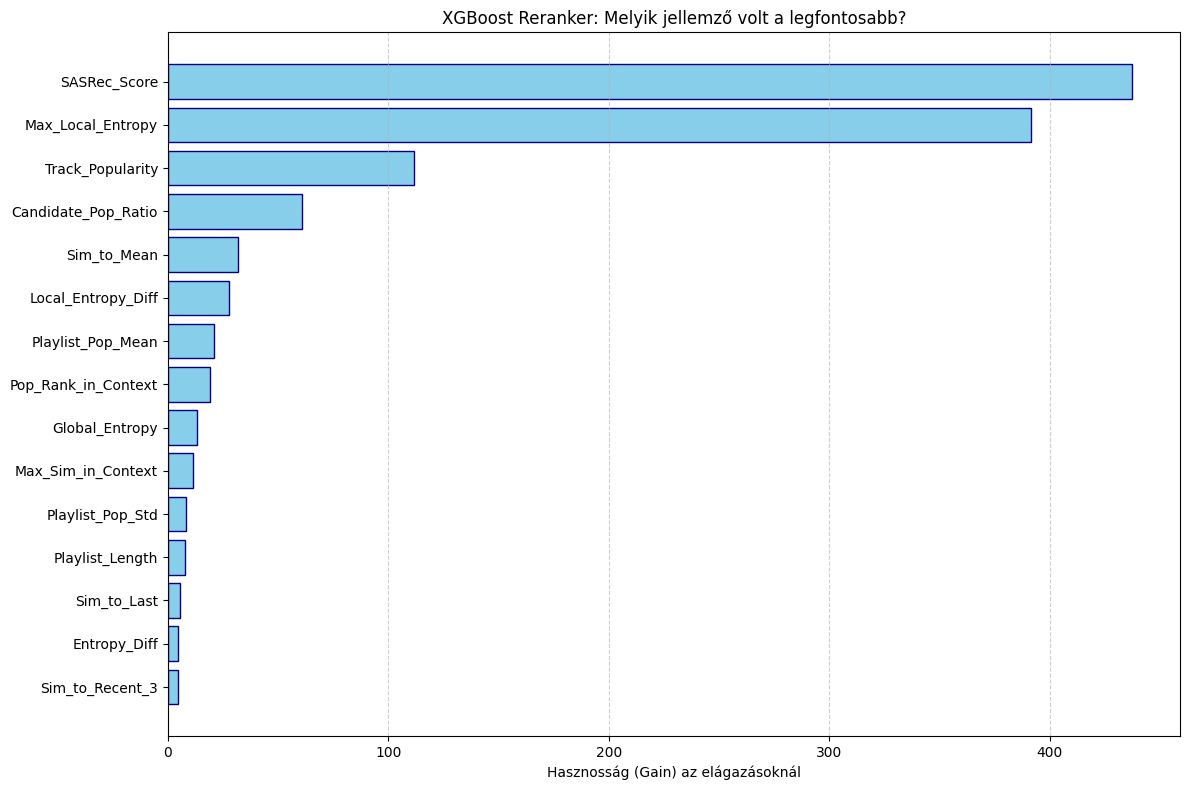


📈 Tanulási görbe...


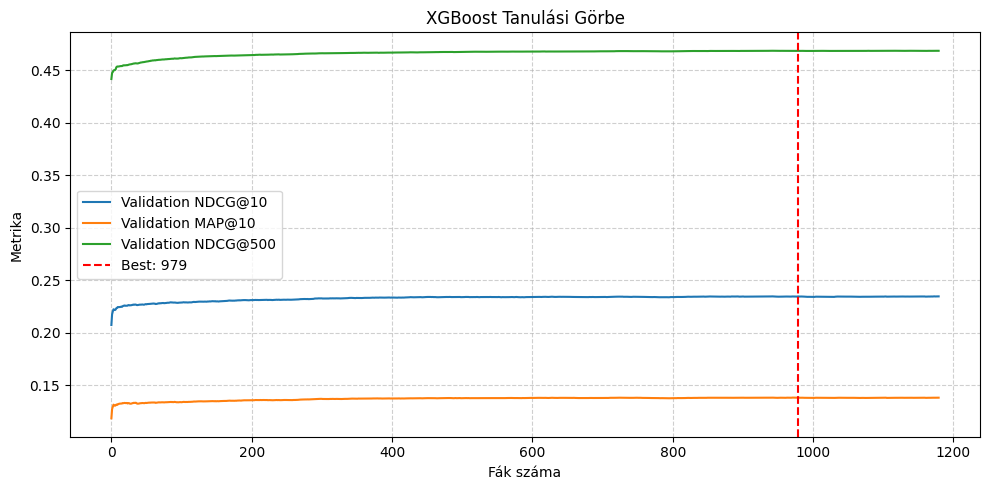

🏆 Legjobb iteráció: 979
🏆 Legjobb NDCG@10: 0.2347


In [2]:
import pandas as pd
import xgboost as xgb
import matplotlib.pyplot as plt

# ==========================================
# 1. ADATBETÖLTÉS ÉS RENDEZÉS
# ==========================================
print("📂 Parquet fájl betöltése...")
df = pd.read_parquet("../Models/xgboost_train_dataset_hybrid_multi_v2_variable_filtered.parquet")  # ← filtered
df = df.sort_values("Playlist_ID").reset_index(drop=True)

# Listán belüli shuffle — pozitív ne legyen mindig elöl
shuffled_parts = []
for pid, group in df.groupby("Playlist_ID"):
    shuffled_parts.append(group.sample(frac=1, random_state=42))
df = pd.concat(shuffled_parts).reset_index(drop=True)

# ==========================================
# 2. JELLEMZŐK DEFINIÁLÁSA
# ==========================================
features = [
    'Playlist_Length',
    #'SASRec_Rank',
    'SASRec_Score',
    'Sim_to_Last',
    'Sim_to_Mean',
    'Sim_to_Recent_3',       # ← ÚJ
    'Max_Sim_in_Context',    # ← ÚJ
    'Track_Popularity',
    'Global_Entropy',
    'Max_Local_Entropy',
    'Playlist_Pop_Mean',
    'Playlist_Pop_Std',
    'Candidate_Pop_Ratio',
    'Pop_Rank_in_Context',   # ← ÚJ
    'Entropy_Diff',
    'Local_Entropy_Diff'
]

X = df[features]
y = df['Label']
groups = df['Playlist_ID']

# ==========================================
# 3. TRAIN-VAL SPLIT
# ==========================================
total_playlists = groups.max()
train_idx = groups < (total_playlists - 5000)

X_train, y_train, qid_train = X[train_idx], y[train_idx], groups[train_idx]
X_val, y_val, qid_val = X[~train_idx], y[~train_idx], groups[~train_idx]

print(f"✅ Tanító halmaz: {len(X_train):,} sor")
print(f"✅ Validációs halmaz: {len(X_val):,} sor")

# ==========================================
# 4. MODELL DEFINÍCIÓ ÉS TANÍTÁS
# ==========================================
print("\n🚀 XGBoost tanítás indítása...")

ranker = xgb.XGBRanker(
    objective='rank:ndcg',
    n_estimators=2000,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=10,
    tree_method='hist',
    random_state=42,
    eval_metric=['ndcg@10', 'ndcg@500', 'map@10'],
    early_stopping_rounds=200
)

ranker.fit(
    X_train, y_train,
    qid=qid_train,
    eval_set=[(X_val, y_val)],
    eval_qid=[qid_val],
    verbose=50
)

# ==========================================
# 5. MENTÉS ÉS VIZUALIZÁCIÓ
# ==========================================
ranker.save_model("../Models/xgboost_reranker_final_hybrid_multi_v2_variable.json")
print("\n💾 Modell sikeresen elmentve!")

print("\n📊 Jellemzők fontosságának (Feature Importance) kirajzolása...")
importance = ranker.get_booster().get_score(importance_type='gain')
sorted_importance = sorted(importance.items(), key=lambda x: x[1], reverse=True)
labels, values = zip(*sorted_importance)

plt.figure(figsize=(12, 8))
plt.barh(labels[::-1], values[::-1], color='skyblue', edgecolor='navy')
plt.xlabel("Hasznosság (Gain) az elágazásoknál")
plt.title("XGBoost Reranker: Melyik jellemző volt a legfontosabb?")
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

print("\n📈 Tanulási görbe...")
results = ranker.evals_result()
plt.figure(figsize=(10, 5))
plt.plot(results['validation_0']['ndcg@10'], label='Validation NDCG@10')
plt.plot(results['validation_0']['map@10'],  label='Validation MAP@10')
plt.plot(results['validation_0']['ndcg@500'], label='Validation NDCG@500')
plt.axvline(x=ranker.best_iteration, color='red', linestyle='--',
            label=f'Best: {ranker.best_iteration}')
plt.legend()
plt.title('XGBoost Tanulási Görbe')
plt.xlabel('Fák száma')
plt.ylabel('Metrika')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

print(f"🏆 Legjobb iteráció: {ranker.best_iteration}")
print(f"🏆 Legjobb NDCG@10: {max(results['validation_0']['ndcg@10']):.4f}")

In [3]:
import random
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers
import faiss
import h5py
from gensim.models import Word2Vec
from tqdm.auto import tqdm
import pyarrow as pa
import pyarrow.parquet as pq
import gc

# ==========================================
# 1. ÚTVONALAK ÉS PARAMÉTEREK
# ==========================================
VAL_DATA_PATH   = "../Models/test_pids.npy"
W2V_MODEL_PATH  = "../Models/song2vec.model"
W2V_MATRIX_PATH = "../Models/hybrid_embedding_matrix.npy"
H5_FILE         = "../Dataset/spotify_dataset_compressed.h5"
WEIGHTS_PATH    = "../Models/best_sasrec_large_hard_w2v_only.weights.h5"
OUTPUT_PARQUET  = "../Models/xgboost_test_dataset_hybrid_multi_v2_variable.parquet"

MAX_LEN    = 50
BATCH_SIZE = 256
TOP_K      = 1000
MIN_GIVEN  = 1
MAX_GIVEN  = 10

# ==========================================
# 2. METAADATOK ÉS SZÓTÁR ELŐTÖLTÉSE
# ==========================================
print("📖 Word2Vec szótár és beágyazások betöltése...")
w2v_model = Word2Vec.load(W2V_MODEL_PATH)
uri_to_id = w2v_model.wv.key_to_index

embeddings = np.load(W2V_MATRIX_PATH).astype('float32')
vocab_size, D_MODEL = embeddings.shape

embeddings_norm = embeddings.copy()
faiss.normalize_L2(embeddings_norm)

print("📈 Dalok népszerűségének kiszámítása...")
track_popularity = np.zeros(vocab_size, dtype=int)
train_playlists = np.load("../Models/train_pids.npy", allow_pickle=True)
for pl in train_playlists[::10]:  # ← minden 10. lista
    for track_id in pl:
        if track_id < vocab_size:
            track_popularity[track_id] += 1

track_global_entropy = np.full(vocab_size, np.nan, dtype=np.float32)
track_max_local_entropy = np.full(vocab_size, np.nan, dtype=np.float32)
track_is_cnn = np.zeros(vocab_size, dtype=int)

print("🧮 HDF5 metaadatok beolvasása...")
with h5py.File(H5_FILE, "r") as hf:
    track_uris_hdf5 = hf["ml/track_uri"][:]
    entropy_global_data = hf["features/markov_entropy_global"][:]
    entropy_local_data = hf["features/markov_entropy_local"][:]

    if isinstance(track_uris_hdf5[0], bytes):
        track_uris_hdf5 = [uri.decode('utf-8') for uri in track_uris_hdf5]

    for hdf5_idx, uri in enumerate(tqdm(track_uris_hdf5, desc="Mapping")):
        if uri in uri_to_id:
            sasrec_id = uri_to_id[uri]
            if sasrec_id < vocab_size:
                track_global_entropy[sasrec_id] = entropy_global_data[hdf5_idx][0]
                track_max_local_entropy[sasrec_id] = np.max(entropy_local_data[hdf5_idx])
                track_is_cnn[sasrec_id] = 1

print(f"❄️ Cold Start szimulálva: {(track_is_cnn == 1).sum():,} dal népszerűsége lenullázva.")
track_popularity[track_is_cnn == 1] = 0

# ==========================================
# 3. SASREC MODELL (INFERENCIA VERZIÓ)
# ==========================================
print("🏗️ SASRec Modell inicializálása...")
def create_inference_model(vocab_size, init_weights):
    seq_inputs = layers.Input(shape=(MAX_LEN,), name="seq_inputs")
    item_embedding = layers.Embedding(
        vocab_size, D_MODEL, mask_zero=True,
        embeddings_initializer=tf.keras.initializers.Constant(init_weights),
        trainable=True, name="w2v_embedding"
    )
    pos_embedding = layers.Embedding(MAX_LEN, D_MODEL, name="pos_embedding")
    x = item_embedding(seq_inputs)
    x += pos_embedding(tf.range(MAX_LEN)[tf.newaxis, :])
    for _ in range(3):
        attn = layers.MultiHeadAttention(num_heads=8, key_dim=D_MODEL//8)(x, x, use_causal_mask=True)
        x = layers.LayerNormalization()(x + layers.Dropout(0.2)(attn))
        ffn = layers.Dense(D_MODEL * 4, activation='relu')(x)
        ffn = layers.Dense(D_MODEL)(ffn)
        x = layers.LayerNormalization()(x + layers.Dropout(0.2)(ffn))
    seq_states = layers.Dense(D_MODEL, name="final_projection")(x)
    return tf.keras.Model(inputs=seq_inputs, outputs=seq_states)

inference_model = create_inference_model(vocab_size, embeddings)
inference_model.load_weights(WEIGHTS_PATH)

print("🔍 FAISS Index építése...")
updated_embeddings = inference_model.get_layer("w2v_embedding").get_weights()[0]
faiss_embeddings = updated_embeddings.copy().astype('float32')
faiss.normalize_L2(faiss_embeddings)
index = faiss.IndexFlatIP(D_MODEL)
index.add(faiss_embeddings)

# ==========================================
# 4. KÖTEGELT TÁBLÁZATGENERÁLÁS (VÁLTOZÓ KONTEXTUS)
# ==========================================
print(f"🚀 Táblázat generálása ({MIN_GIVEN}-{MAX_GIVEN} adott dal)...")
val_playlists = np.load(VAL_DATA_PATH, allow_pickle=True)
val_playlists = np.array([[t for t in pl if t != 0] for pl in val_playlists], dtype=object)
val_playlists = val_playlists[::10]  # ← minden 10. playlist
print(f"📋 Felhasznált playlists: {len(val_playlists):,}")

dataset_rows = []
global_playlist_id = 0
writer = None

for i in tqdm(range(0, len(val_playlists), BATCH_SIZE), desc="Feldolgozás"):
    batch_lists = val_playlists[i : i + BATCH_SIZE]

    all_contexts, all_targets = [], []

    for pl in batch_lists:
        if len(pl) <= MIN_GIVEN:
            continue
        for given_n in range(MIN_GIVEN, min(MAX_GIVEN, len(pl) - 1) + 1):
            context = pl[:given_n]
            target_set = set(pl[given_n:])
            all_contexts.append(context)
            all_targets.append(target_set)

    if not all_contexts:
        continue

    batch_padded = []
    for context in all_contexts:
        input_seq = context[-MAX_LEN:]
        batch_padded.append([0] * (MAX_LEN - len(input_seq)) + list(input_seq))

    pred_vectors = inference_model.predict_on_batch(np.array(batch_padded))
    target_pred_vectors = pred_vectors[:, -1, :].astype('float32')
    faiss.normalize_L2(target_pred_vectors)
    raw_scores, raw_indices = index.search(target_pred_vectors, TOP_K + MAX_LEN)

    for b_idx in range(len(all_contexts)):
        context = all_contexts[b_idx]
        actual_targets = all_targets[b_idx]
        num_targets = len(actual_targets)

        last_track_vec = embeddings_norm[context[-1]]
        playlist_mean_vec = np.mean(embeddings_norm[context], axis=0)
        playlist_mean_vec /= (np.linalg.norm(playlist_mean_vec) + 1e-8)

        context_pops = [track_popularity[t] for t in context]
        playlist_pop_mean = float(np.mean(context_pops))
        playlist_pop_std = float(np.std(context_pops))

        context_entropies = [track_global_entropy[t] for t in context
                             if not np.isnan(track_global_entropy[t])]
        playlist_entropy_mean = float(np.mean(context_entropies)) if context_entropies else 0.0

        context_local_entropies = [track_max_local_entropy[t] for t in context
                                   if not np.isnan(track_max_local_entropy[t])]
        playlist_local_entropy_mean = float(np.mean(context_local_entropies)) if context_local_entropies else 0.0

        recent_3 = context[-3:] if len(context) >= 3 else context
        recent_3_vecs = embeddings_norm[recent_3]
        context_pops_arr = np.array(context_pops)
        context_vecs = embeddings_norm[list(context)]

        pos_samples, neg_samples = [], []
        current_rank = 1

        for score, cand_id in zip(raw_scores[b_idx], raw_indices[b_idx]):
            if cand_id in context or cand_id == 0:
                continue
            if len(pos_samples) + len(neg_samples) >= TOP_K:
                break

            is_target = 1 if cand_id in actual_targets else 0
            cand_vec = embeddings_norm[cand_id]
            cand_pop = track_popularity[cand_id]
            cand_entropy = track_global_entropy[cand_id]
            cand_local_entropy = track_max_local_entropy[cand_id]

            pop_ratio = cand_pop / (playlist_pop_mean + 1.0)
            entropy_diff = abs(cand_entropy - playlist_entropy_mean) if not np.isnan(cand_entropy) else -1.0
            local_entropy_diff = abs(cand_local_entropy - playlist_local_entropy_mean) if not np.isnan(cand_local_entropy) else -1.0
            sim_to_recent_3 = float(np.mean(recent_3_vecs @ cand_vec))
            max_sim_in_context = float(np.max(context_vecs @ cand_vec))
            pop_rank_in_context = float(np.mean(context_pops_arr > cand_pop))

            row = {
                "Playlist_ID":         global_playlist_id,
                "Candidate_ID":        cand_id,
                "Playlist_Length":     len(context),
                "Num_Targets":         num_targets,
                "SASRec_Rank":         current_rank,
                "SASRec_Score":        float(score),
                "Sim_to_Last":         float(np.dot(last_track_vec, cand_vec)),
                "Sim_to_Mean":         float(np.dot(playlist_mean_vec, cand_vec)),
                "Sim_to_Recent_3":     sim_to_recent_3,
                "Max_Sim_in_Context":  max_sim_in_context,
                "Track_Popularity":    cand_pop,
                "Global_Entropy":      cand_entropy,
                "Max_Local_Entropy":   cand_local_entropy,
                "Playlist_Pop_Mean":   playlist_pop_mean,
                "Playlist_Pop_Std":    playlist_pop_std,
                "Candidate_Pop_Ratio": float(pop_ratio),
                "Pop_Rank_in_Context": pop_rank_in_context,
                "Entropy_Diff":        float(entropy_diff),
                "Local_Entropy_Diff":  float(local_entropy_diff),
                "Label":               is_target
            }

            if is_target:
                pos_samples.append(row)
            else:
                neg_samples.append(row)
            current_rank += 1

        dataset_rows.extend(pos_samples)
        dataset_rows.extend(neg_samples)
        global_playlist_id += 1

    if len(dataset_rows) >= 500_000:
        df_chunk = pd.DataFrame(dataset_rows)
        table = pa.Table.from_pandas(df_chunk)
        if writer is None:
            writer = pq.ParquetWriter(OUTPUT_PARQUET, table.schema)
        writer.write_table(table)
        dataset_rows.clear()
        del df_chunk, table
        gc.collect()

# ==========================================
# 5. MARADÉK KIÍRÁSA ÉS FÁJL LEZÁRÁSA
# ==========================================
print("💾 Maradék adatok mentése és fájl lezárása...")
if len(dataset_rows) > 0:
    df_chunk = pd.DataFrame(dataset_rows)
    table = pa.Table.from_pandas(df_chunk)
    if writer is None:
        writer = pq.ParquetWriter(OUTPUT_PARQUET, table.schema)
    writer.write_table(table)

if writer is not None:
    writer.close()

# ==========================================
# 6. SZŰRÉS
# ==========================================
print("🧹 Pozitív nélküli listák szűrése...")
df = pd.read_parquet(OUTPUT_PARQUET)
lists_with_pos = df[df['Label'] == 1]['Playlist_ID'].unique()
df_filtered = df[df['Playlist_ID'].isin(lists_with_pos)].reset_index(drop=True)
df_filtered.to_parquet(OUTPUT_PARQUET.replace('.parquet', '_filtered.parquet'), index=False)

print(f"🎉 KÉSZ! Generált sorok: {len(df):,} → Szűrt sorok: {len(df_filtered):,}")
del df, df_filtered
gc.collect()

📖 Word2Vec szótár és beágyazások betöltése...
📈 Dalok népszerűségének kiszámítása...
🧮 HDF5 metaadatok beolvasása...


Mapping:   0%|          | 0/27052 [00:00<?, ?it/s]

❄️ Cold Start szimulálva: 25,511 dal népszerűsége lenullázva.
🏗️ SASRec Modell inicializálása...
🔍 FAISS Index építése...
🚀 Táblázat generálása (1-10 adott dal)...
📋 Felhasznált playlists: 9,918


Feldolgozás:   0%|          | 0/39 [00:00<?, ?it/s]

💾 Maradék adatok mentése és fájl lezárása...
🧹 Pozitív nélküli listák szűrése...


ArrowMemoryError: malloc of size 8569792000 failed

In [1]:
import pandas as pd
import numpy as np
import xgboost as xgb

# ==========================================
# 1. ADATOK ÉS MODELL BETÖLTÉSE
# ==========================================
df_test = pd.read_parquet("../Models/xgboost_test_dataset_hybrid_multi_v2_variable.parquet")

features = [
    'Playlist_Length', 'SASRec_Score', 'Sim_to_Last', 'Sim_to_Mean',
    'Sim_to_Recent_3', 'Max_Sim_in_Context', 'Track_Popularity',
    'Global_Entropy', 'Max_Local_Entropy', 'Playlist_Pop_Mean',
    'Playlist_Pop_Std', 'Candidate_Pop_Ratio', 'Pop_Rank_in_Context',
    'Entropy_Diff', 'Local_Entropy_Diff'
]

ranker = xgb.XGBRanker()
ranker.load_model("../Models/xgboost_reranker_final_hybrid_multi_v2_variable.json") 

df_test['XGB_Score'] = ranker.predict(df_test[features])

df_test['XGB_Rank'] = df_test.groupby('Playlist_ID')['XGB_Score'].rank(
    ascending=False, method='first'
).astype(int)

# ==========================================
# 2. ÚJ MULTI-TARGET KIÉRTÉKELŐ FÜGGVÉNY
# ==========================================
def calculate_metrics_multi(df, rank_col, k_list, default_num_targets=25):
    results = {k: {'Recall': 0.0, 'NDCG': 0.0} for k in k_list}
    total_clicks = 0
    total_r_prec = 0.0
    
    grouped = df.groupby('Playlist_ID')
    total_queries = len(grouped)
    
    if total_queries == 0:
        return pd.DataFrame(), 0, 0
    
    for pid, group in grouped:
        if 'Num_Targets' in group.columns:
            num_targets = group['Num_Targets'].iloc[0]
        else:
            num_targets = default_num_targets
            
        hits = group[group['Label'] == 1]
        hit_ranks = hits[rank_col].values.tolist()
        hit_ranks.sort() 
        
        if len(hit_ranks) > 0:
            first_hit = hit_ranks[0]
            if first_hit <= 500:
                clicks = (first_hit - 1) // 10
            else:
                clicks = 51
        else:
            clicks = 51
        total_clicks += clicks
        
        hits_in_r = sum(1 for r in hit_ranks if r <= num_targets)
        total_r_prec += (hits_in_r / num_targets) if num_targets > 0 else 0
        
        for k in k_list:
            k_hits = [r for r in hit_ranks if r <= k]
            if num_targets > 0:
                results[k]['Recall'] += len(k_hits) / num_targets
                dcg = sum(1.0 / np.log2(r + 1) for r in k_hits)
                idcg_len = min(k, num_targets)
                idcg = sum(1.0 / np.log2(pos + 1) for pos in range(1, idcg_len + 1))
                if idcg > 0:
                    results[k]['NDCG'] += (dcg / idcg)

    final_results = []
    for k in k_list:
        final_results.append({
            'k': k, 
            'Recall': results[k]['Recall'] / total_queries, 
            'NDCG': results[k]['NDCG'] / total_queries
        })
        
    avg_clicks = total_clicks / total_queries
    avg_r_prec = total_r_prec / total_queries
    
    return pd.DataFrame(final_results), avg_clicks, avg_r_prec

# ==========================================
# 3. KIÉRTÉKELÉS KÜLÖN SEED MÉRETEKRE (1-10)
# ==========================================
K_VALUES = [1, 5, 10, 20, 50, 100, 200, 500]

# Lekérjük a teszthalmazban lévő összes létező seed hosszt (1, 2, ... 10)
seed_lengths = sorted(df_test['Playlist_Length'].unique())

for seed_len in seed_lengths:
    # Leszűrjük csak az aktuális seed méretre
    df_subset = df_test[df_test['Playlist_Length'] == seed_len]
    
    print("\n" + "━"*70)
    print(f"🎯 EREDMÉNYEK: {seed_len} MEGADOTT DAL (SEED) ESETÉN")
    print("━"*70)
    
    sas_m, sas_c, sas_r = calculate_metrics_multi(df_subset, 'SASRec_Rank', K_VALUES)
    xgb_m, xgb_c, xgb_r = calculate_metrics_multi(df_subset, 'XGB_Rank', K_VALUES)

    summary = sas_m.set_index('k').join(xgb_m.set_index('k'), lsuffix='_SAS', rsuffix='_XGB')

    for m in ['Recall', 'NDCG']:
        summary[f'{m}_imp%'] = (summary[f'{m}_XGB'] - summary[f'{m}_SAS']) / summary[f'{m}_SAS'] * 100

    pd.options.display.float_format = '{:.4f}'.format
    cols = [c for m in ['Recall','NDCG'] for c in [f'{m}_SAS', f'{m}_XGB', f'{m}_imp%']]
    print(summary[cols].T.to_string())

    print(f"\n🎯 R-Precision SASRec:  {sas_r:.4f}")
    print(f"🎯 R-Precision XGBoost: {xgb_r:.4f}")
    if sas_r > 0:
        print(f"🚀 R-Precision javulás: {(xgb_r - sas_r)/sas_r*100:.2f}%\n")

    print(f"🖱️ Clicks SASRec:  {sas_c:.4f}")
    print(f"🖱️ Clicks XGBoost: {xgb_c:.4f}")
    if sas_c > 0:
        print(f"🚀 Clicks javulás: {(xgb_c - sas_c)/sas_c*100:.2f}%")


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
🎯 EREDMÉNYEK: 1 MEGADOTT DAL (SEED) ESETÉN
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
k              1      5      10      20      50      100     200     500
Recall_SAS  0.0063 0.0240 0.0402  0.0632  0.1069  0.1514  0.2052  0.2918
Recall_XGB  0.0065 0.0262 0.0440  0.0701  0.1213  0.1745  0.2424  0.3369
Recall_imp% 3.0757 9.0338 9.3802 11.0236 13.4200 15.2618 18.1543 15.4675
NDCG_SAS    0.2483 0.2067 0.1853  0.1615  0.1443  0.1499  0.1704  0.2089
NDCG_XGB    0.2594 0.2249 0.2029  0.1791  0.1627  0.1711  0.1979  0.2404
NDCG_imp%   4.4661 8.7871 9.5171 10.8895 12.7906 14.1289 16.1138 15.0513

🎯 R-Precision SASRec:  0.0955
🎯 R-Precision XGBoost: 0.1109
🚀 R-Precision javulás: 16.14%

🖱️ Clicks SASRec:  6.2993
🖱️ Clicks XGBoost: 4.4919
🚀 Clicks javulás: -28.69%

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
🎯 EREDMÉNYEK: 2 MEGADOTT DAL (SEED) ESETÉN
━━━━━━━━━━━━━━━━━━

# Entrópia nélkül

📂 Parquet fájl betöltése...
✅ Tanító halmaz: 89,895,000 sor
✅ Validációs halmaz: 4,878,000 sor

🚀 XGBoost tanítás indítása...
[0]	validation_0-ndcg@10:0.20626	validation_0-ndcg@500:0.42785	validation_0-map@10:0.11810
[50]	validation_0-ndcg@10:0.22269	validation_0-ndcg@500:0.44670	validation_0-map@10:0.12823
[100]	validation_0-ndcg@10:0.22769	validation_0-ndcg@500:0.45164	validation_0-map@10:0.13254
[150]	validation_0-ndcg@10:0.22917	validation_0-ndcg@500:0.45393	validation_0-map@10:0.13402
[200]	validation_0-ndcg@10:0.23021	validation_0-ndcg@500:0.45508	validation_0-map@10:0.13513
[250]	validation_0-ndcg@10:0.23080	validation_0-ndcg@500:0.45608	validation_0-map@10:0.13564
[300]	validation_0-ndcg@10:0.23124	validation_0-ndcg@500:0.45654	validation_0-map@10:0.13598
[350]	validation_0-ndcg@10:0.23159	validation_0-ndcg@500:0.45724	validation_0-map@10:0.13627
[400]	validation_0-ndcg@10:0.23156	validation_0-ndcg@500:0.45749	validation_0-map@10:0.13641
[450]	validation_0-ndcg@10:0.23154	valid

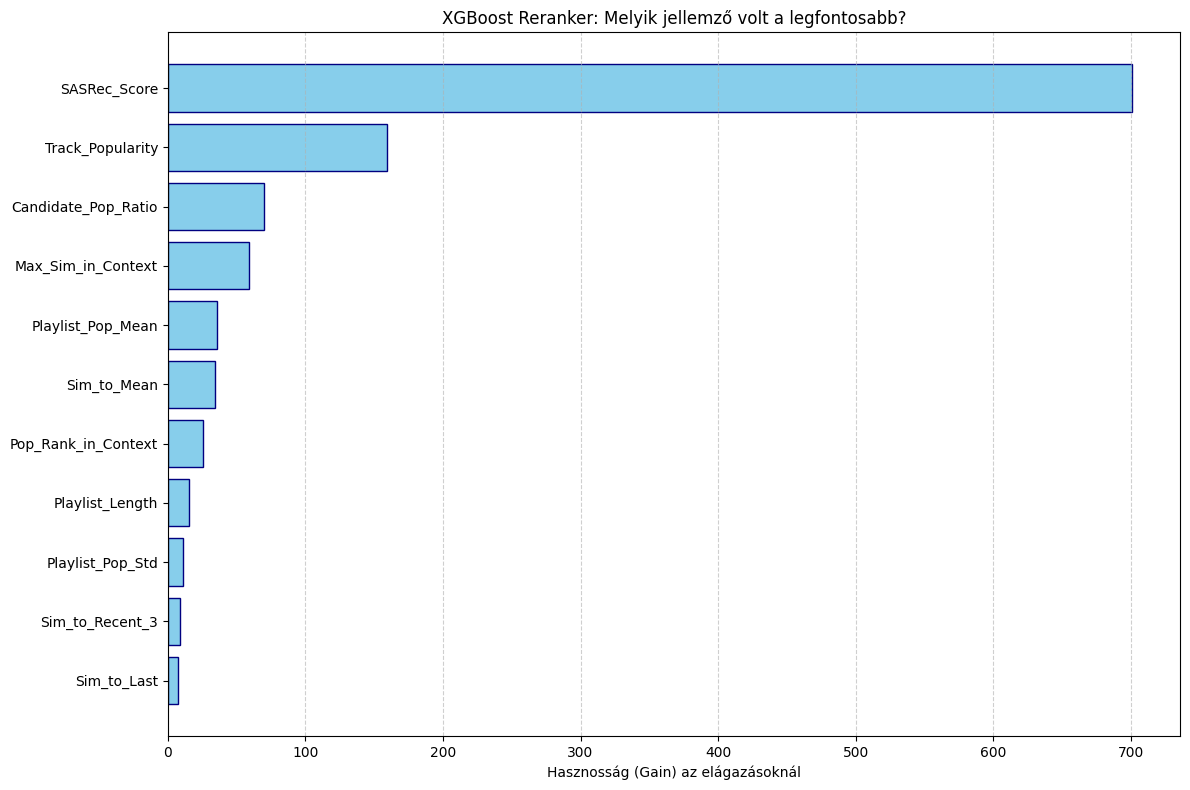


📈 Tanulási görbe...


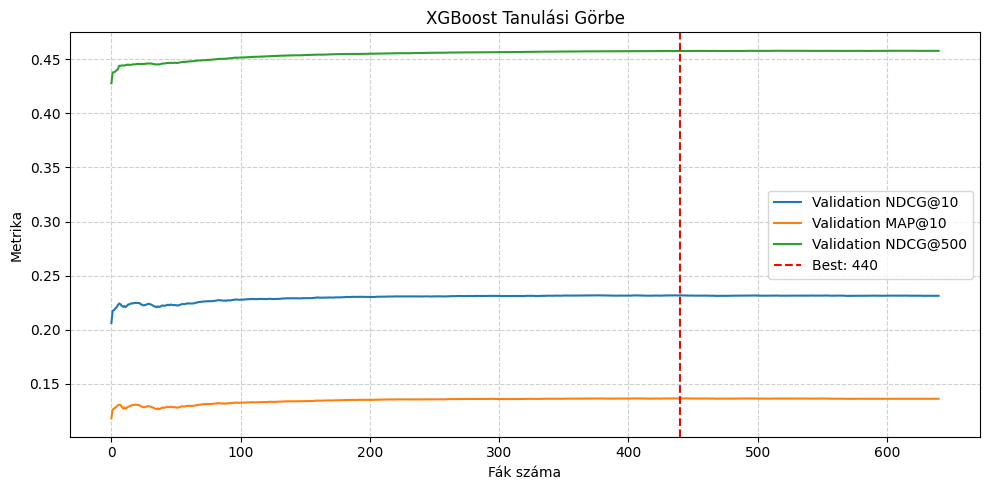

🏆 Legjobb iteráció: 440
🏆 Legjobb NDCG@10: 0.2318


In [1]:
import pandas as pd
import xgboost as xgb
import matplotlib.pyplot as plt

# ==========================================
# 1. ADATBETÖLTÉS ÉS RENDEZÉS
# ==========================================
print("📂 Parquet fájl betöltése...")
df = pd.read_parquet("../Models/xgboost_train_dataset_hybrid_multi_v2_variable_filtered.parquet")  # ← filtered
df = df.sort_values("Playlist_ID").reset_index(drop=True)

# Listán belüli shuffle — pozitív ne legyen mindig elöl
shuffled_parts = []
for pid, group in df.groupby("Playlist_ID"):
    shuffled_parts.append(group.sample(frac=1, random_state=42))
df = pd.concat(shuffled_parts).reset_index(drop=True)

# ==========================================
# 2. JELLEMZŐK DEFINIÁLÁSA
# ==========================================
features = [
    'Playlist_Length',
    #'SASRec_Rank',
    'SASRec_Score',
    'Sim_to_Last',
    'Sim_to_Mean',
    'Sim_to_Recent_3',       # ← ÚJ
    'Max_Sim_in_Context',    # ← ÚJ
    'Track_Popularity',
    'Playlist_Pop_Mean',
    'Playlist_Pop_Std',
    'Candidate_Pop_Ratio',
    'Pop_Rank_in_Context'
]

X = df[features]
y = df['Label']
groups = df['Playlist_ID']

# ==========================================
# 3. TRAIN-VAL SPLIT
# ==========================================
total_playlists = groups.max()
train_idx = groups < (total_playlists - 5000)

X_train, y_train, qid_train = X[train_idx], y[train_idx], groups[train_idx]
X_val, y_val, qid_val = X[~train_idx], y[~train_idx], groups[~train_idx]

print(f"✅ Tanító halmaz: {len(X_train):,} sor")
print(f"✅ Validációs halmaz: {len(X_val):,} sor")

# ==========================================
# 4. MODELL DEFINÍCIÓ ÉS TANÍTÁS
# ==========================================
print("\n🚀 XGBoost tanítás indítása...")

ranker = xgb.XGBRanker(
    objective='rank:ndcg',
    n_estimators=2000,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=10,
    tree_method='hist',
    random_state=42,
    eval_metric=['ndcg@10', 'ndcg@500', 'map@10'],
    early_stopping_rounds=200
)

ranker.fit(
    X_train, y_train,
    qid=qid_train,
    eval_set=[(X_val, y_val)],
    eval_qid=[qid_val],
    verbose=50
)

# ==========================================
# 5. MENTÉS ÉS VIZUALIZÁCIÓ
# ==========================================
ranker.save_model("../Models/xgboost_reranker_final_hybrid_multi_v3_variable.json")
print("\n💾 Modell sikeresen elmentve!")

print("\n📊 Jellemzők fontosságának (Feature Importance) kirajzolása...")
importance = ranker.get_booster().get_score(importance_type='gain')
sorted_importance = sorted(importance.items(), key=lambda x: x[1], reverse=True)
labels, values = zip(*sorted_importance)

plt.figure(figsize=(12, 8))
plt.barh(labels[::-1], values[::-1], color='skyblue', edgecolor='navy')
plt.xlabel("Hasznosság (Gain) az elágazásoknál")
plt.title("XGBoost Reranker: Melyik jellemző volt a legfontosabb?")
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

print("\n📈 Tanulási görbe...")
results = ranker.evals_result()
plt.figure(figsize=(10, 5))
plt.plot(results['validation_0']['ndcg@10'], label='Validation NDCG@10')
plt.plot(results['validation_0']['map@10'],  label='Validation MAP@10')
plt.plot(results['validation_0']['ndcg@500'], label='Validation NDCG@500')
plt.axvline(x=ranker.best_iteration, color='red', linestyle='--',
            label=f'Best: {ranker.best_iteration}')
plt.legend()
plt.title('XGBoost Tanulási Görbe')
plt.xlabel('Fák száma')
plt.ylabel('Metrika')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

print(f"🏆 Legjobb iteráció: {ranker.best_iteration}")
print(f"🏆 Legjobb NDCG@10: {max(results['validation_0']['ndcg@10']):.4f}")

In [2]:
import pandas as pd
import numpy as np
import xgboost as xgb

# ==========================================
# 1. ADATOK ÉS MODELL BETÖLTÉSE
# ==========================================
df_test = pd.read_parquet("../Models/xgboost_test_dataset_hybrid_multi_v2_variable.parquet")

features = [
    'Playlist_Length', 'SASRec_Score', 'Sim_to_Last', 'Sim_to_Mean',
    'Sim_to_Recent_3', 'Max_Sim_in_Context', 'Track_Popularity', 'Playlist_Pop_Mean',
    'Playlist_Pop_Std', 'Candidate_Pop_Ratio', 'Pop_Rank_in_Context'
]

ranker = xgb.XGBRanker()
ranker.load_model("../Models/xgboost_reranker_final_hybrid_multi_v3_variable.json") 

df_test['XGB_Score'] = ranker.predict(df_test[features])

df_test['XGB_Rank'] = df_test.groupby('Playlist_ID')['XGB_Score'].rank(
    ascending=False, method='first'
).astype(int)

# ==========================================
# 2. ÚJ MULTI-TARGET KIÉRTÉKELŐ FÜGGVÉNY
# ==========================================
def calculate_metrics_multi(df, rank_col, k_list, default_num_targets=25):
    results = {k: {'Recall': 0.0, 'NDCG': 0.0} for k in k_list}
    total_clicks = 0
    total_r_prec = 0.0
    
    grouped = df.groupby('Playlist_ID')
    total_queries = len(grouped)
    
    if total_queries == 0:
        return pd.DataFrame(), 0, 0
    
    for pid, group in grouped:
        if 'Num_Targets' in group.columns:
            num_targets = group['Num_Targets'].iloc[0]
        else:
            num_targets = default_num_targets
            
        hits = group[group['Label'] == 1]
        hit_ranks = hits[rank_col].values.tolist()
        hit_ranks.sort() 
        
        if len(hit_ranks) > 0:
            first_hit = hit_ranks[0]
            if first_hit <= 500:
                clicks = (first_hit - 1) // 10
            else:
                clicks = 51
        else:
            clicks = 51
        total_clicks += clicks
        
        hits_in_r = sum(1 for r in hit_ranks if r <= num_targets)
        total_r_prec += (hits_in_r / num_targets) if num_targets > 0 else 0
        
        for k in k_list:
            k_hits = [r for r in hit_ranks if r <= k]
            if num_targets > 0:
                results[k]['Recall'] += len(k_hits) / num_targets
                dcg = sum(1.0 / np.log2(r + 1) for r in k_hits)
                idcg_len = min(k, num_targets)
                idcg = sum(1.0 / np.log2(pos + 1) for pos in range(1, idcg_len + 1))
                if idcg > 0:
                    results[k]['NDCG'] += (dcg / idcg)

    final_results = []
    for k in k_list:
        final_results.append({
            'k': k, 
            'Recall': results[k]['Recall'] / total_queries, 
            'NDCG': results[k]['NDCG'] / total_queries
        })
        
    avg_clicks = total_clicks / total_queries
    avg_r_prec = total_r_prec / total_queries
    
    return pd.DataFrame(final_results), avg_clicks, avg_r_prec

# ==========================================
# 3. KIÉRTÉKELÉS KÜLÖN SEED MÉRETEKRE (1-10)
# ==========================================
K_VALUES = [1, 5, 10, 20, 50, 100, 200, 500]

# Lekérjük a teszthalmazban lévő összes létező seed hosszt (1, 2, ... 10)
seed_lengths = sorted(df_test['Playlist_Length'].unique())

for seed_len in seed_lengths:
    # Leszűrjük csak az aktuális seed méretre
    df_subset = df_test[df_test['Playlist_Length'] == seed_len]
    
    print("\n" + "━"*70)
    print(f"🎯 EREDMÉNYEK: {seed_len} MEGADOTT DAL (SEED) ESETÉN")
    print("━"*70)
    
    sas_m, sas_c, sas_r = calculate_metrics_multi(df_subset, 'SASRec_Rank', K_VALUES)
    xgb_m, xgb_c, xgb_r = calculate_metrics_multi(df_subset, 'XGB_Rank', K_VALUES)

    summary = sas_m.set_index('k').join(xgb_m.set_index('k'), lsuffix='_SAS', rsuffix='_XGB')

    for m in ['Recall', 'NDCG']:
        summary[f'{m}_imp%'] = (summary[f'{m}_XGB'] - summary[f'{m}_SAS']) / summary[f'{m}_SAS'] * 100

    pd.options.display.float_format = '{:.4f}'.format
    cols = [c for m in ['Recall','NDCG'] for c in [f'{m}_SAS', f'{m}_XGB', f'{m}_imp%']]
    print(summary[cols].T.to_string())

    print(f"\n🎯 R-Precision SASRec:  {sas_r:.4f}")
    print(f"🎯 R-Precision XGBoost: {xgb_r:.4f}")
    if sas_r > 0:
        print(f"🚀 R-Precision javulás: {(xgb_r - sas_r)/sas_r*100:.2f}%\n")

    print(f"🖱️ Clicks SASRec:  {sas_c:.4f}")
    print(f"🖱️ Clicks XGBoost: {xgb_c:.4f}")
    if sas_c > 0:
        print(f"🚀 Clicks javulás: {(xgb_c - sas_c)/sas_c*100:.2f}%")


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
🎯 EREDMÉNYEK: 1 MEGADOTT DAL (SEED) ESETÉN
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
k              1      5      10     20      50      100     200     500
Recall_SAS  0.0063 0.0240 0.0402 0.0632  0.1069  0.1514  0.2052  0.2918
Recall_XGB  0.0064 0.0257 0.0434 0.0690  0.1187  0.1694  0.2308  0.3293
Recall_imp% 2.7009 7.2397 7.8134 9.2063 11.0424 11.8536 12.4865 12.8688
NDCG_SAS    0.2483 0.2067 0.1853 0.1615  0.1443  0.1499  0.1704  0.2089
NDCG_XGB    0.2559 0.2226 0.2005 0.1768  0.1598  0.1671  0.1909  0.2348
NDCG_imp%   3.0451 7.6579 8.2391 9.4317 10.7599 11.4348 11.9892 12.4005

🎯 R-Precision SASRec:  0.0955
🎯 R-Precision XGBoost: 0.1080
🚀 R-Precision javulás: 13.04%

🖱️ Clicks SASRec:  6.2993
🖱️ Clicks XGBoost: 4.8273
🚀 Clicks javulás: -23.37%

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
🎯 EREDMÉNYEK: 2 MEGADOTT DAL (SEED) ESETÉN
━━━━━━━━━━━━━━━━━━━━━━━━━